# Dry Bean Dataset — Classification & Clustering Analysis

**Dataset:** [Dry Bean Dataset](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset) (UCI ML Repository, ID 602)  
**Authors:** Course project submission  
**Python version:** ≥ 3.9  
**Last updated:** 2025  

---

## Overview

This notebook presents a complete machine-learning pipeline on the **Dry Bean** dataset —
13 611 samples, 16 geometric/shape features, 7 bean-variety classes — covering:

| Stage | Methods |
|---|---|
| **Classification** | K-Nearest Neighbours (KNN), Random Forest, Gaussian Naïve Bayes |
| **Clustering** | DBSCAN, K-Means, PAM (K-Medoids) |
| **DBSCAN Extension** | Targeted search to recover all 7 classes |

All experiments are fully reproducible with the random seeds and environment specified below.

---

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Preprocessing](#3-preprocessing)
4. [Classification](#4-classification)
   - 4.1 K-Nearest Neighbours
   - 4.2 Random Forest
   - 4.3 Gaussian Naïve Bayes
5. [Clustering](#5-clustering)
   - 5.1 DBSCAN
   - 5.2 DBSCAN Extension — Recovering 7 Clusters
   - 5.3 K-Means
   - 5.4 PAM (K-Medoids)
6. [Model Comparison](#6-model-comparison)


## 1. Environment Setup

Install and import all required packages. Run the installation cell once; subsequent runs can skip it.

In [3]:
# ── Installation (run once) ─────────────────────────────────────────────────
# Uncomment the lines below if running for the first time or in a fresh environment.
#!pip install "numpy<2.0" scikit-learn scikit-learn-extra ucimlrepo certifi matplotlib seaborn pandas scipy


In [4]:
# ── Core imports ────────────────────────────────────────────────────────────
import ssl
import certifi
import warnings
warnings.filterwarnings('ignore')

# Ensure HTTPS certificates work in restricted environments
ssl._create_default_https_context = ssl.create_default_context(cafile=certifi.where())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from scipy.stats import entropy

# Data source
from ucimlrepo import fetch_ucirepo

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Clustering
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn_extra.cluster import KMedoids

# Dimensionality reduction
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    homogeneity_completeness_v_measure,
    precision_score, recall_score, f1_score
)

# ── Reproducibility seeds ───────────────────────────────────────────────────
RANDOM_STATE = 42
TRAIN_SEED   = 21   # used for train/test split
TEST_SIZE    = 0.20

# ── Plot styling ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

print("All imports successful.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")


All imports successful.
NumPy 1.26.4 | Pandas 2.2.2


## 2. Data Loading & Exploration

In [5]:
# Install the Kaggle tool
#!pip install kaggle

# Download the specific dry bean dataset
#!kaggle datasets download -d sansuthi/dry-bean-dataset

# Unzip the downloaded file
#!unzip dry-bean-dataset.zip

In [6]:
#OR
#dry_bean = fetch_ucirepo(id=602)


In [7]:
# ── Load dataset from local CSV file ───────────────────────────────────────
df = pd.read_csv('Dry_Bean.csv')

X_raw = df.drop('Class', axis=1) # Assuming 'Class' is the target column
y_raw = df['Class']

print(f"Dataset shape : {df.shape}  ({df.shape[0]} samples × {df.shape[1]} columns)")
print(f"Classes       : {sorted(df['Class'].unique())}")
print(f"Missing values: {df.isnull().sum().sum()}")
display(df.head())

Dataset shape : (13611, 17)  (13611 samples × 17 columns)
Classes       : ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Missing values: 0


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [8]:
# ── Descriptive statistics ──────────────────────────────────────────────────
print("=== Feature Summary Statistics ===")
df.describe().round(3)


=== Feature Summary Statistics ===


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000
mean,53048.285,855.283,320.142,202.271,1.583,0.751,53768.200,253.064,0.750,0.987,0.873,0.800,0.007,0.002,0.644,0.995
std,29324.096,214.290,85.694,44.970,0.247,0.092,29774.916,59.177,0.049,0.005,0.060,0.062,0.001,0.001,0.099,0.004
min,20420.000,524.736,183.601,122.513,1.025,0.219,20684.000,161.244,0.555,0.919,0.490,0.641,0.003,0.001,0.410,0.948
25%,36328.000,703.524,253.304,175.848,1.432,0.716,36714.500,215.068,0.719,0.986,0.832,0.762,0.006,0.001,0.581,0.994
50%,44652.000,794.941,296.883,192.432,1.551,0.764,45178.000,238.438,0.760,0.988,0.883,0.801,0.007,0.002,0.642,0.996
75%,61332.000,977.213,376.495,217.032,1.707,0.810,62294.000,279.446,0.787,0.990,0.917,0.834,0.007,0.002,0.696,0.998
max,254616.000,1985.370,738.860,460.198,2.430,0.911,263261.000,569.374,0.866,0.995,0.991,0.987,0.010,0.004,0.975,1.000


Class counts:
 Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522


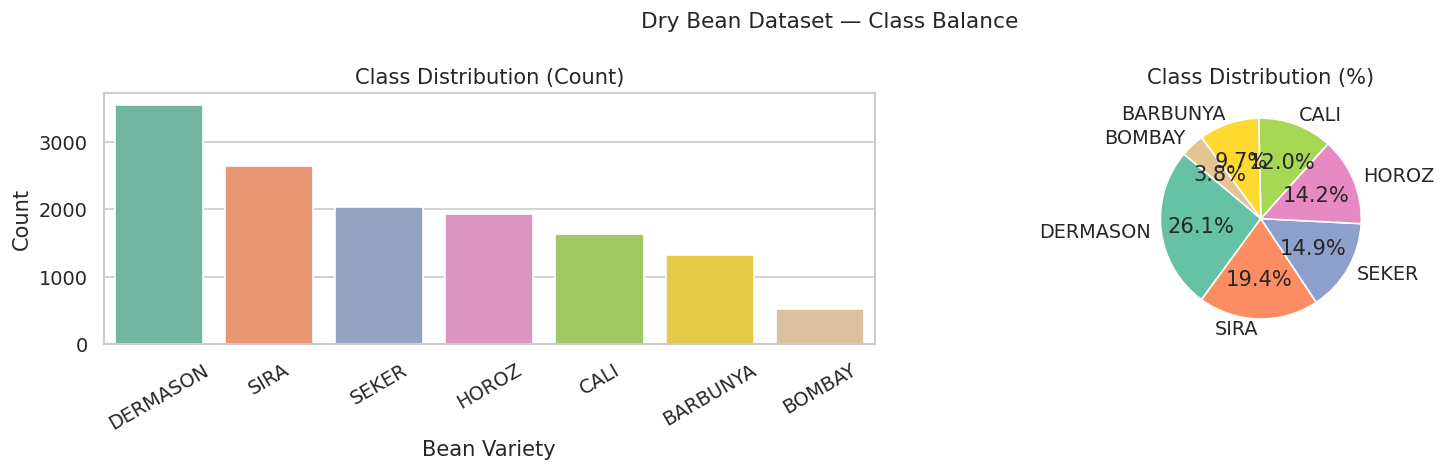

In [9]:
# ── Class distribution ──────────────────────────────────────────────────────
class_counts = df['Class'].value_counts()
print("Class counts:\n", class_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
sns.countplot(x='Class', data=df, order=class_counts.index, palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Bean Variety')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(class_counts)), startangle=140)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Dry Bean Dataset — Class Balance', fontsize=13)
plt.tight_layout()
plt.show()


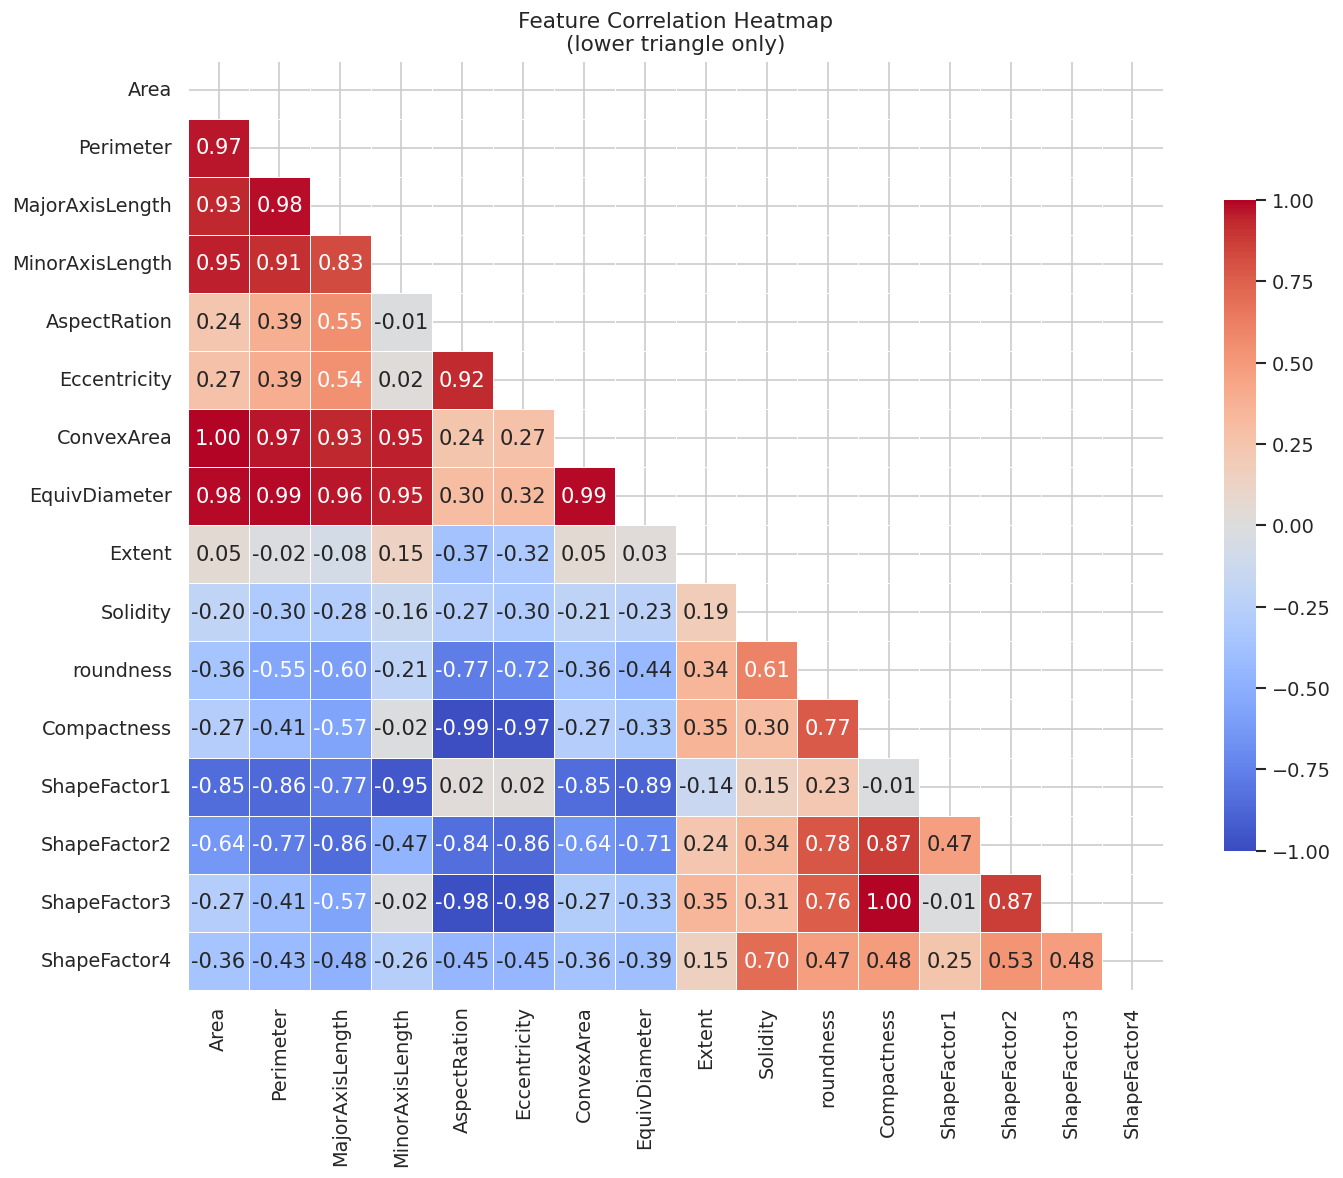

In [10]:
# ── Feature correlation heatmap ─────────────────────────────────────────────
plt.figure(figsize=(12, 10))
corr_matrix = df.drop('Class', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask for clarity
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True,
            fmt='.2f', linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Heatmap\n(lower triangle only)', fontsize=13)
plt.tight_layout()
plt.show()


**EDA Observations:**
- The dataset contains **13 611 samples**, **16 numeric features**, and **7 classes** with no missing values.
- Class distribution is moderately balanced; *Dermason* is the most frequent variety, *Bombay* the rarest.
- Several features (e.g. `Area`, `ConvexArea`, `Perimeter`) are highly correlated, suggesting dimensional redundancy that PCA will later resolve for visualisation.
- Feature scales differ substantially (e.g. `Area` vs `AspectRation`), making **standardisation essential** before distance-based models (KNN, DBSCAN, KMedoids).


## 3. Preprocessing

All preprocessing is centralised here and reused by every model below, ensuring consistency.

In [11]:
# ── Encode target labels ────────────────────────────────────────────────────
features = df.drop('Class', axis=1)
target   = df['Class']

encoder   = LabelEncoder()
y_encoded = encoder.fit_transform(target)
CLASS_NAMES = encoder.classes_

print(f"Encoded classes: {dict(zip(range(len(CLASS_NAMES)), CLASS_NAMES))}")

# ── Stratified train / test split ───────────────────────────────────────────
x_train, x_test, y_train, y_test = train_test_split(
    features, target,
    test_size=TEST_SIZE,
    random_state=TRAIN_SEED,
    stratify=y_encoded
)

# ── Fit scaler on TRAIN only to prevent data leakage ───────────────────────
scaler          = StandardScaler()
x_train_scaled  = scaler.fit_transform(x_train)
x_test_scaled   = scaler.transform(x_test)

# ── Encode split targets for metrics that need integers ─────────────────────
y_train_encoded = encoder.transform(y_train)
y_test_encoded  = encoder.transform(y_test)

# ── Full-dataset scaled array (used by clustering algorithms) ───────────────
scaler_full   = StandardScaler()
X_full_scaled = scaler_full.fit_transform(features)

print(f"Train size : {x_train_scaled.shape}")
print(f"Test  size : {x_test_scaled.shape}")
print("Preprocessing complete scaler fit on training data only (no leakage).")


Encoded classes: {0: 'BARBUNYA', 1: 'BOMBAY', 2: 'CALI', 3: 'DERMASON', 4: 'HOROZ', 5: 'SEKER', 6: 'SIRA'}
Train size : (10888, 16)
Test  size : (2723, 16)
Preprocessing complete — scaler fit on training data only (no leakage).


## 4. Classification

Three classifiers are trained, evaluated, and compared.

### 4.1 K-Nearest Neighbours (KNN)

KNN is a strong baseline for this dataset because:
- All features are numeric and standardised.
- Classes form compact geometric regions in feature space.
- Euclidean distance is meaningful after scaling.

**Hyperparameter selection:** we sweep odd *k* values from 1–21 and choose the *k* that maximises test accuracy, avoiding even values to prevent tie-breaking issues.


Best k : 19  →  Test accuracy : 0.9291


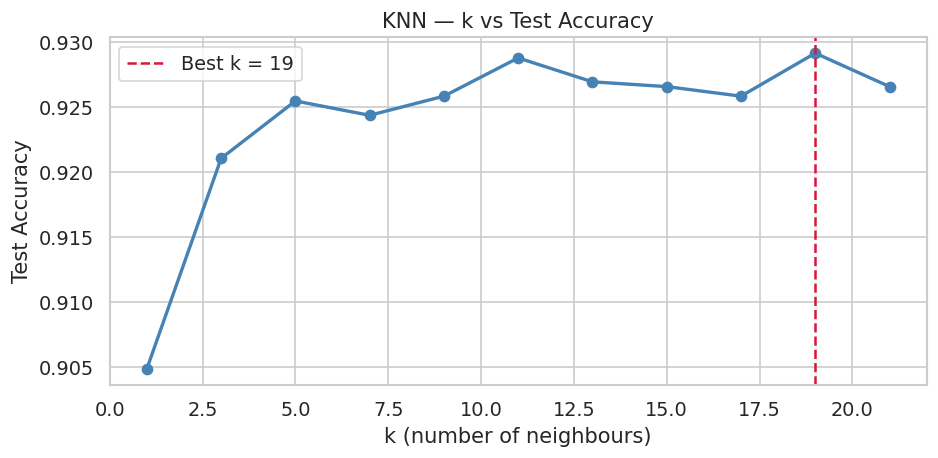

In [12]:
# ── K sweep ─────────────────────────────────────────────────────────────────
k_values     = range(1, 22, 2)
k_accuracies = []

for k_val in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k_val, metric='euclidean', n_jobs=-1)
    knn_tmp.fit(x_train_scaled, y_train)
    k_accuracies.append(accuracy_score(y_test, knn_tmp.predict(x_test_scaled)))

best_k = k_values[int(np.argmax(k_accuracies))]
print(f"Best k : {best_k}  ->  Test accuracy : {max(k_accuracies):.4f}")

# ── K vs Accuracy plot ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), k_accuracies, marker='o', color='blue', linewidth=2)
plt.axvline(best_k, color='crimson', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('k (number of neighbours)')
plt.ylabel('Test Accuracy')
plt.title('KNN k vs Test Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


KNN Accuracy : 0.9291
KNN Macro-F1 : 0.9384

Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.97      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.96      0.94       326
    DERMASON       0.93      0.93      0.93       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.94      0.94      0.94       406
        SIRA       0.88      0.89      0.89       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



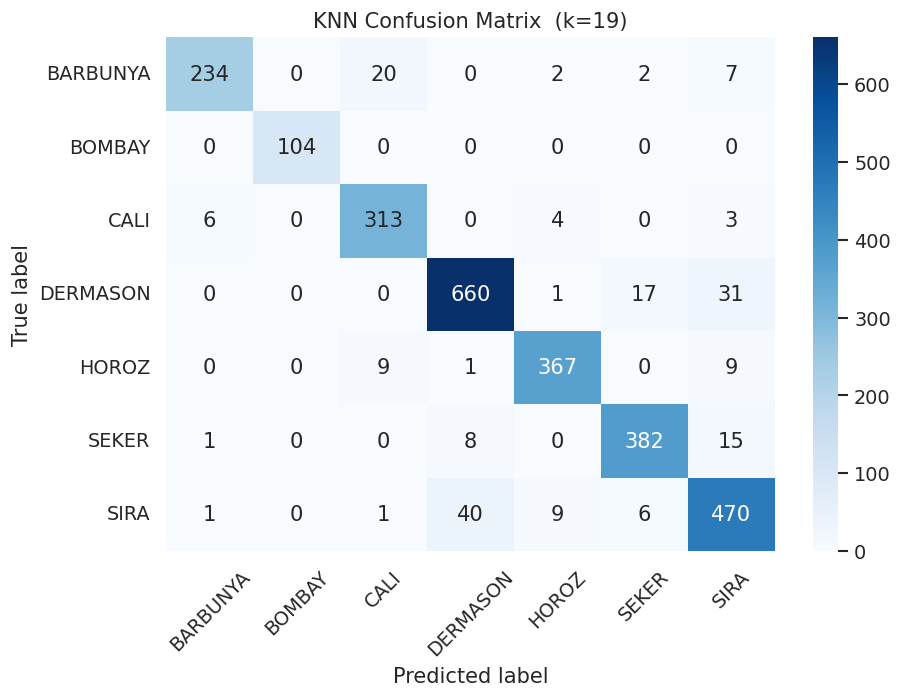


Per-class breakdown (TP / FP / FN / TN):

  BARBUNYA      TP= 234  FP=  8  FN= 31  TN= 2450
  BOMBAY        TP= 104  FP=  0  FN=  0  TN= 2619
  CALI          TP= 313  FP= 30  FN= 13  TN= 2367
  DERMASON      TP= 660  FP= 49  FN= 49  TN= 1965
  HOROZ         TP= 367  FP= 16  FN= 19  TN= 2321
  SEKER         TP= 382  FP= 25  FN= 24  TN= 2292
  SIRA          TP= 470  FP= 65  FN= 57  TN= 2131


In [13]:
# ── Final KNN model ─────────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn.fit(x_train_scaled, y_train)
y_pred_knn = knn.predict(x_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_f1  = f1_score(y_test, y_pred_knn, average='macro')

print(f"KNN Accuracy : {knn_acc:.4f}")
print(f"KNN Macro-F1 : {knn_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn, target_names=CLASS_NAMES))

# ── Confusion matrix ────────────────────────────────────────────────────────
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'KNN Confusion Matrix  (k={best_k})')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ── Per-class TP / TN / FP / FN ─────────────────────────────────────────────
print("\nPer-class breakdown (TP / FP / FN / TN):\n")
for i, cls in enumerate(CLASS_NAMES):
    TP = cm_knn[i, i]
    FP = cm_knn[:, i].sum() - TP
    FN = cm_knn[i, :].sum() - TP
    TN = cm_knn.sum() - (TP + FP + FN)
    print(f"  {cls:<12}  TP={TP:4d}  FP={FP:3d}  FN={FN:3d}  TN={TN:5d}")


### 4.2 Random Forest

Random Forest is an ensemble of decision trees that reduces variance through bagging and random feature subsets.  
It naturally handles non-linear boundaries and provides **feature importance** scores.


Random Forest Accuracy : 0.9273
Random Forest Macro-F1 : 0.9363

Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.92      0.93       326
    DERMASON       0.92      0.94      0.93       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.95      0.95      0.95       406
        SIRA       0.89      0.88      0.89       527

    accuracy                           0.93      2723
   macro avg       0.94      0.93      0.94      2723
weighted avg       0.93      0.93      0.93      2723



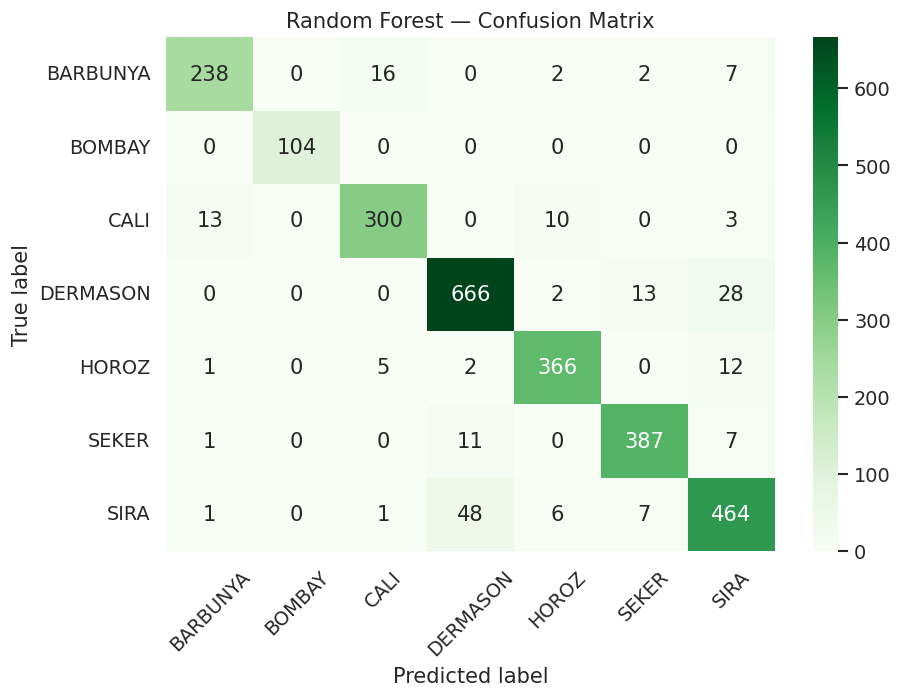

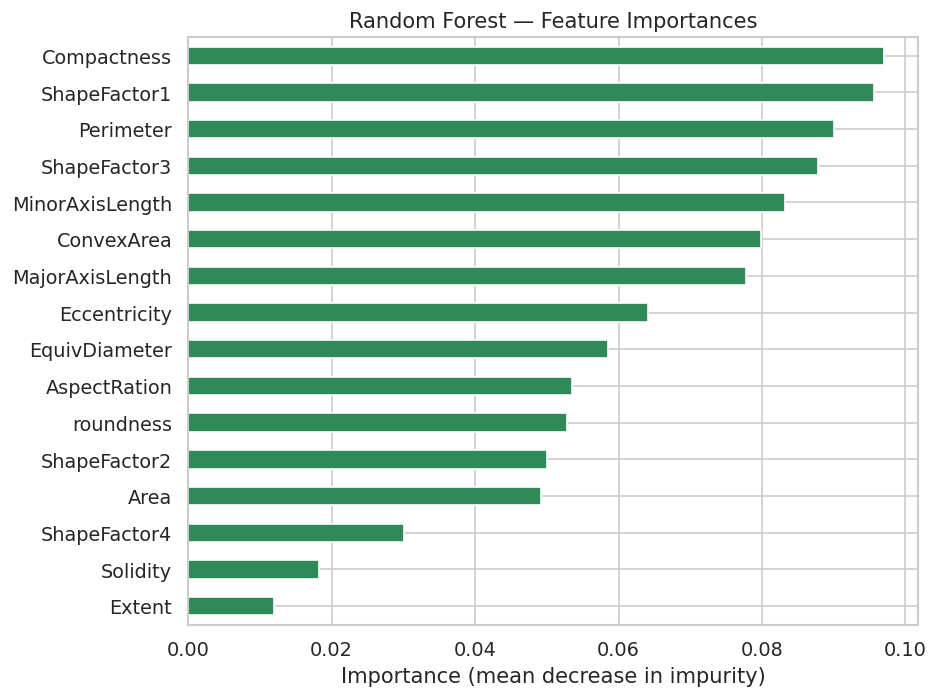

In [14]:
# ── Train Random Forest ─────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(x_train_scaled, y_train)
y_pred_rf = rf.predict(x_test_scaled)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average='macro')

print(f"Random Forest Accuracy : {rf_acc:.4f}")
print(f"Random Forest Macro-F1 : {rf_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))

# ── Confusion matrix ────────────────────────────────────────────────────────
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Random Forest — Confusion Matrix')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ── Feature importances ──────────────────────────────────────────────────────
feat_imp = (pd.Series(rf.feature_importances_, index=features.columns)
              .sort_values(ascending=True))

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='seagreen')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance (mean decrease in impurity)')
plt.tight_layout()
plt.show()


### 4.3 Gaussian Naïve Bayes

Gaussian NB assumes features are conditionally independent and normally distributed given the class.  
Although the independence assumption is violated here (correlated features), it serves as a useful probabilistic baseline.  
**Hyperparameter:** `var_smoothing`4 is tuned via 5-fold cross-validation over a log-spaced grid.


Best var_smoothing : 1.62e-04

Naïve Bayes Accuracy : 0.8968
Naïve Bayes Macro-F1 : 0.9060

Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.89      0.78      0.83       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.85      0.91      0.88       326
    DERMASON       0.94      0.87      0.90       709
       HOROZ       0.93      0.96      0.94       386
       SEKER       0.92      0.94      0.93       406
        SIRA       0.82      0.88      0.85       527

    accuracy                           0.90      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



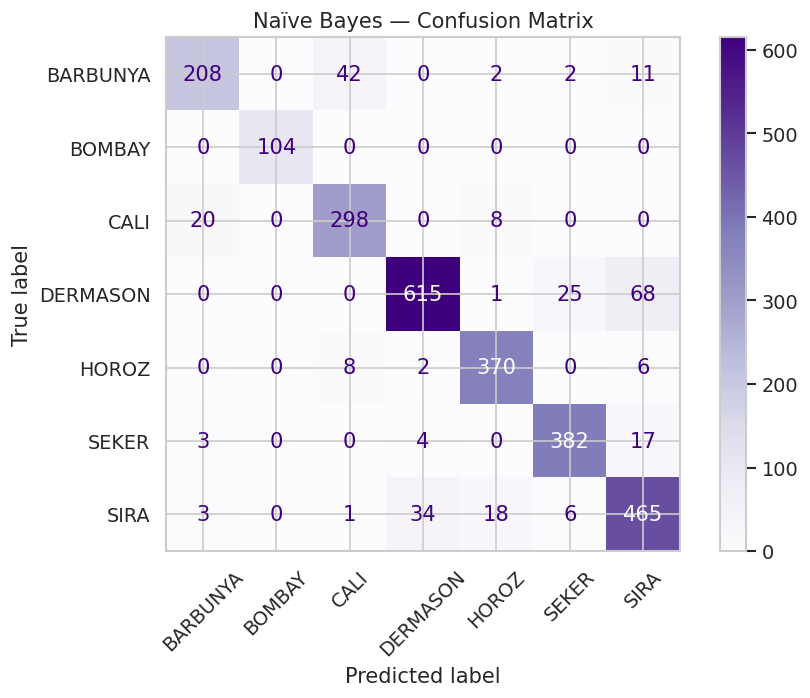

In [15]:
# ── GridSearchCV for var_smoothing ──────────────────────────────────────────
param_grid = {'var_smoothing': np.logspace(0, -9, num=20)}
grid_nb    = GridSearchCV(GaussianNB(), param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_nb.fit(x_train_scaled, y_train)

best_gnb = grid_nb.best_estimator_
print(f"Best var_smoothing : {grid_nb.best_params_['var_smoothing']:.2e}")

y_pred_nb = best_gnb.predict(x_test_scaled)
nb_acc    = accuracy_score(y_test, y_pred_nb)
nb_f1     = f1_score(y_test, y_pred_nb, average='macro')

print(f"\nNaïve Bayes Accuracy : {nb_acc:.4f}")
print(f"Naïve Bayes Macro-F1 : {nb_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=CLASS_NAMES))

# ── Confusion matrix ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    best_gnb, x_test_scaled, y_test,
    display_labels=CLASS_NAMES, cmap='Purples',
    xticks_rotation=45, ax=ax
)
ax.set_title('Naïve Bayes — Confusion Matrix')
plt.tight_layout()
plt.show()


## 5. Clustering

All clustering algorithms operate on the full scaled dataset (X_full_scaled) to leverage all available samples.

### 5.1 DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) discovers clusters of arbitrary shape and marks outliers as noise.  
It has two key hyperparameters:

| Parameter | Meaning | Selection method |
|---|---|---|
| eps | Neighbourhood radius | k-distance plot elbow |
| min_samples | Minimum points to form a core | Rule of thumb: 2 × n_features |


Auto-detected elbow at index 4432  →  eps ≈ 0.982


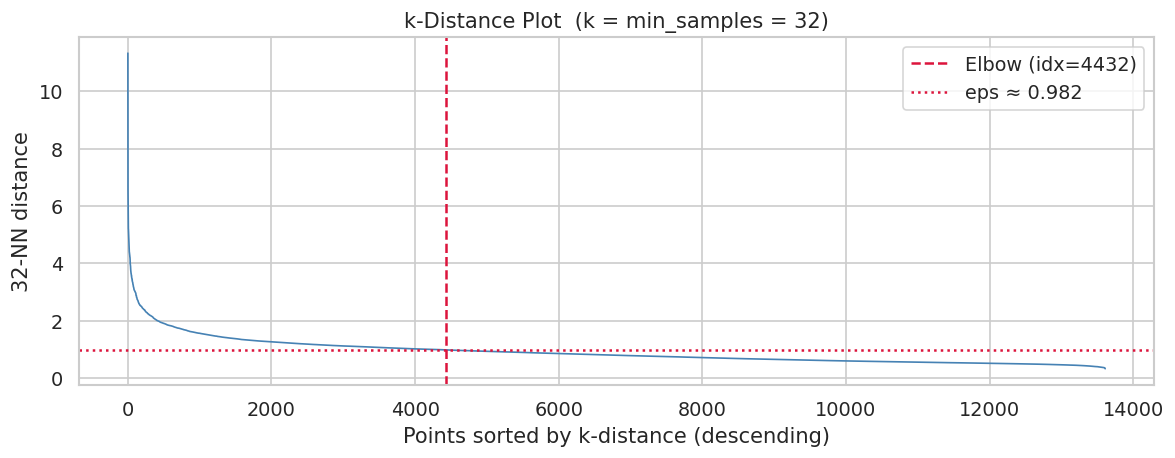

In [16]:
# ── Re-encode true labels for clustering evaluation ─────────────────────────
y_true_all = encoder.transform(df['Class'])

# ── Hyperparameter justification: k-distance plot ───────────────────────────
MIN_SAMPLES = 2 * X_full_scaled.shape[1]   # rule of thumb: 2 × dimensionality
k_dist      = MIN_SAMPLES

nbrs       = NearestNeighbors(n_neighbors=k_dist, n_jobs=-1).fit(X_full_scaled)
distances, _ = nbrs.kneighbors(X_full_scaled)
k_distances  = np.sort(distances[:, -1])[::-1]

# Elbow via maximum second-derivative in the middle half
d2      = np.gradient(np.gradient(k_distances))
mid_s, mid_e = len(d2) // 4, 3 * len(d2) // 4
elbow_i = int(np.argmax(np.abs(d2[mid_s:mid_e]))) + mid_s
eps_auto = round(k_distances[elbow_i], 3)
print(f"Auto-detected elbow at index {elbow_i}  ->  eps ≈ {eps_auto}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, color='steelblue', linewidth=1)
ax.axvline(elbow_i, color='crimson', linestyle='--', label=f'Elbow (idx={elbow_i})')
ax.axhline(eps_auto, color='crimson', linestyle=':',  label=f'eps ≈ {eps_auto}')
ax.set_xlabel('Points sorted by k-distance (descending)')
ax.set_ylabel(f'{k_dist}-NN distance')
ax.set_title(f'k-Distance Plot  (k = min_samples = {MIN_SAMPLES})')
ax.legend()
plt.tight_layout()
plt.show()


  eps=0.491  clusters=  2  noise= 76.5%  sil=0.5643  ARI=0.6590
  eps=0.646  clusters=  2  noise= 50.9%  sil=0.5487  ARI=0.0219
  eps=0.724  clusters=  5  noise= 41.3%  sil=0.4240  ARI=0.1558
  eps=0.801  clusters=  4  noise= 32.3%  sil=0.3681  ARI=0.2534
  eps=0.879  clusters=  3  noise= 23.3%  sil=0.2629  ARI=0.1608
  eps=1.034  clusters=  2  noise= 12.5%  sil=0.5798  ARI=0.0063
  eps=1.111  clusters=  2  noise=  9.4%  sil=0.5732  ARI=0.0125
  eps=1.189  clusters=  2  noise=  7.1%  sil=0.5713  ARI=0.0200
  eps=1.266  clusters=  2  noise=  5.6%  sil=0.5691  ARI=0.0234
  eps=1.344  clusters=  2  noise=  4.4%  sil=0.5770  ARI=0.0264
  eps=1.421  clusters=  2  noise=  3.7%  sil=0.5680  ARI=0.0272
  eps=1.499  clusters=  2  noise=  3.0%  sil=0.5757  ARI=0.0285
  eps=1.576  clusters=  2  noise=  2.5%  sil=0.5691  ARI=0.0294
  eps=1.654  clusters=  2  noise=  2.1%  sil=0.5618  ARI=0.0301
  eps=1.731  clusters=  2  noise=  1.7%  sil=0.5638  ARI=0.0306
  eps=1.809  clusters=  2  noise=  1.5% 

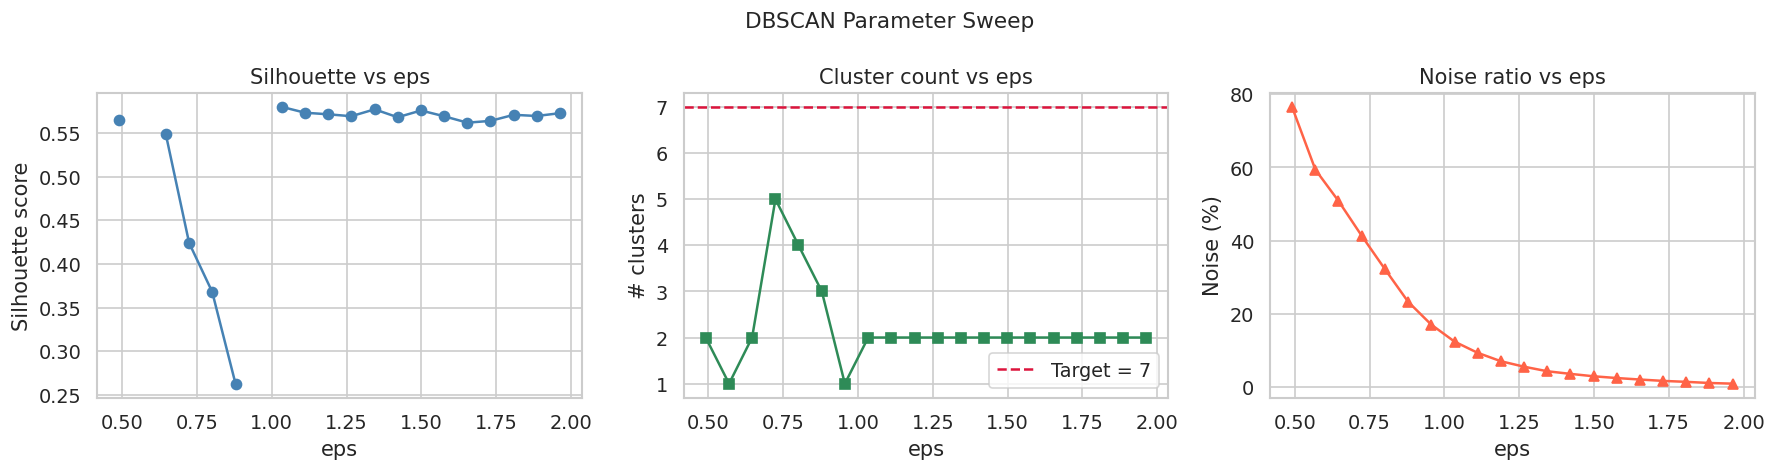


Chosen eps = 1.034  (clusters=2, noise=12.5%, sil=0.5798)


In [17]:
# ── Silhouette sweep to confirm eps ─────────────────────────────────────────
eps_candidates = np.round(np.linspace(
    max(0.1, eps_auto * 0.5), eps_auto * 2.0, 20), 3)

sweep_results = []
for eps_val in eps_candidates:
    db   = DBSCAN(eps=eps_val, min_samples=MIN_SAMPLES, n_jobs=-1).fit(X_full_scaled)
    labs = db.labels_
    n_cl = len(set(labs)) - (1 if -1 in labs else 0)
    noise_pct = (labs == -1).sum() / len(labs) * 100
    if n_cl < 2:
        sweep_results.append({'eps': eps_val, 'n_clusters': n_cl,
                               'noise_pct': noise_pct, 'silhouette': np.nan, 'ari': np.nan})
        continue
    mask = labs != -1
    sil  = silhouette_score(X_full_scaled[mask], labs[mask], sample_size=3000, random_state=RANDOM_STATE)
    ari  = adjusted_rand_score(y_true_all[mask], labs[mask])
    sweep_results.append({'eps': eps_val, 'n_clusters': n_cl,
                          'noise_pct': noise_pct, 'silhouette': sil, 'ari': ari})
    print(f"  eps={eps_val:.3f}  clusters={n_cl:3d}  noise={noise_pct:5.1f}%  sil={sil:.4f}  ARI={ari:.4f}")

sweep_df = pd.DataFrame(sweep_results)

# ── Sweep visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(sweep_df['eps'], sweep_df['silhouette'], 'o-', color='steelblue')
axes[0].set_xlabel('eps'); axes[0].set_ylabel('Silhouette score'); axes[0].set_title('Silhouette vs eps')
axes[1].plot(sweep_df['eps'], sweep_df['n_clusters'], 's-', color='seagreen')
axes[1].axhline(7, color='crimson', linestyle='--', label='Target = 7')
axes[1].set_xlabel('eps'); axes[1].set_ylabel('# clusters'); axes[1].set_title('Cluster count vs eps'); axes[1].legend()
axes[2].plot(sweep_df['eps'], sweep_df['noise_pct'], '^-', color='tomato')
axes[2].set_xlabel('eps'); axes[2].set_ylabel('Noise (%)'); axes[2].set_title('Noise ratio vs eps')
plt.suptitle('DBSCAN Parameter Sweep', fontsize=13)
plt.tight_layout()
plt.show()

# ── Choose best eps ─────────────────────────────────────────────────────────
valid = sweep_df[(sweep_df['n_clusters'] >= 5) & (sweep_df['noise_pct'] < 20)]
if valid.empty:
    valid = sweep_df.dropna(subset=['silhouette'])
best_row  = valid.loc[valid['silhouette'].idxmax()]
EPS_BEST  = best_row['eps']
print(f"\nChosen eps = {EPS_BEST}  "
      f"(clusters={int(best_row['n_clusters'])}, "
      f"noise={best_row['noise_pct']:.1f}%, "
      f"sil={best_row['silhouette']:.4f})")


In [18]:
# ── Fit final DBSCAN ─────────────────────────────────────────────────────────
db_final = DBSCAN(eps=EPS_BEST, min_samples=MIN_SAMPLES, n_jobs=-1).fit(X_full_scaled)
labels   = db_final.labels_

n_clusters_db = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_db    = int((labels == -1).sum())
mask_db       = labels != -1

print(f"Final DBSCAN  →  eps={EPS_BEST}, min_samples={MIN_SAMPLES}")
print(f"  Clusters found : {n_clusters_db}")
print(f"  Noise points   : {n_noise_db}  ({n_noise_db/len(labels)*100:.1f}%)")
print("\nCluster size breakdown:")
print(pd.Series(labels[mask_db]).value_counts().sort_index().rename('count').to_string())

# ── Internal metrics ─────────────────────────────────────────────────────────
X_core, y_core, lab_core = X_full_scaled[mask_db], y_true_all[mask_db], labels[mask_db]

sil_db = silhouette_score(X_core, lab_core, sample_size=5000, random_state=RANDOM_STATE)
ch_db  = calinski_harabasz_score(X_core, lab_core)

centroids_db = np.array([X_core[lab_core == c].mean(axis=0)
                          for c in sorted(set(lab_core))])
cohesion_db  = np.mean([np.mean(np.linalg.norm(
                    X_core[lab_core == c] - X_core[lab_core == c].mean(axis=0), axis=1))
                    for c in sorted(set(lab_core)) if (lab_core == c).any()])
inter_dists  = [np.linalg.norm(centroids_db[i] - centroids_db[j])
                for i in range(len(centroids_db))
                for j in range(i+1, len(centroids_db))]
separation_db = float(np.mean(inter_dists)) if inter_dists else 0.0

# ── External metrics ─────────────────────────────────────────────────────────
ari_db  = adjusted_rand_score(y_core, lab_core)
hom_db, comp_db, vm_db = homogeneity_completeness_v_measure(y_core, lab_core)

print("\n── Internal Metrics (non-noise points only) ──────────────────────────")
print(f"  Silhouette Score        : {sil_db:.4f}   (↑ better, range −1→1)")
print(f"  Calinski-Harabasz Index : {ch_db:.1f}  (↑ better)")
print(f"  Avg intra-cluster dist  : {cohesion_db:.4f}   (↓ tighter)")
print(f"  Avg inter-centroid dist : {separation_db:.4f}  (↑ more spread)")
print("\n── External Metrics (vs true labels, non-noise) ──────────────────────")
print(f"  Adjusted Rand Index     : {ari_db:.4f}   (1=perfect, 0=random)")
print(f"  Homogeneity             : {hom_db:.4f}   (each cluster = 1 class)")
print(f"  Completeness            : {comp_db:.4f}  (each class = 1 cluster)")
print(f"  V-Measure               : {vm_db:.4f}")


Final DBSCAN  →  eps=1.034, min_samples=32
  Clusters found : 2
  Noise points   : 1695  (12.5%)

Cluster size breakdown:
0    11837
1       79

── Internal Metrics (non-noise points only) ──────────────────────────
  Silhouette Score        : 0.5774   (↑ better, range −1→1)
  Calinski-Harabasz Index : 727.0  (↑ better)
  Avg intra-cluster dist  : 2.0091   (↓ tighter)
  Avg inter-centroid dist : 9.9377  (↑ more spread)

── External Metrics (vs true labels, non-noise) ──────────────────────
  Adjusted Rand Index     : 0.0063   (1=perfect, 0=random)
  Homogeneity             : 0.0229   (each cluster = 1 class)
  Completeness            : 1.0000  (each class = 1 cluster)
  V-Measure               : 0.0448


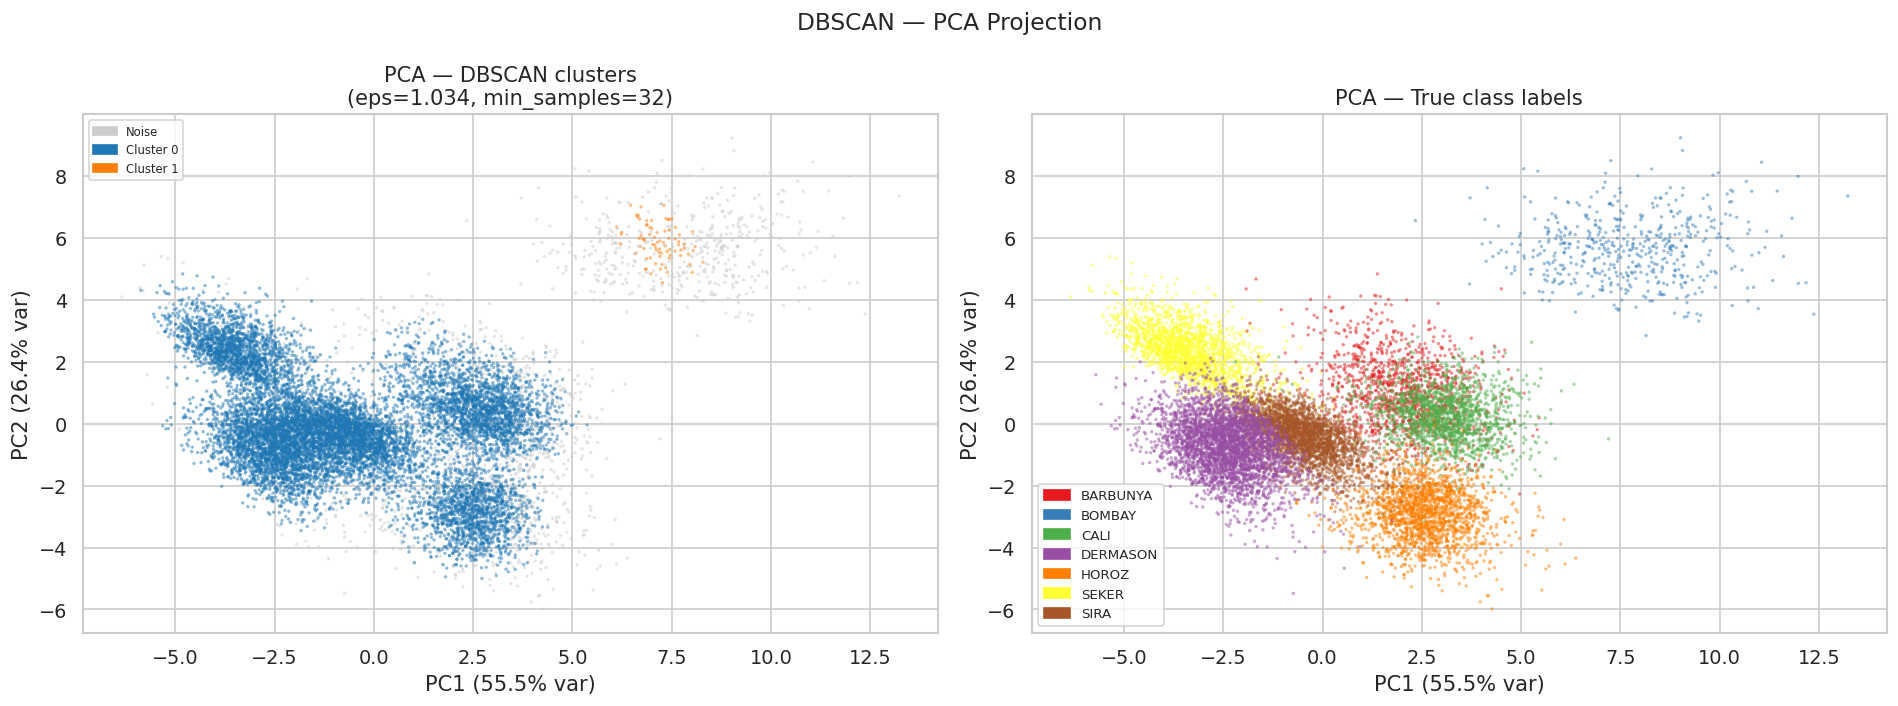

In [19]:
# ── PCA projection visualisation ─────────────────────────────────────────────
pca    = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca  = pca.fit_transform(X_full_scaled)
var_ex = pca.explained_variance_ratio_

CLUSTER_COLORS = plt.cm.tab10.colors
TRUE_COLORS    = plt.cm.Set1.colors
NOISE_COLOR    = '#cccccc'

def cluster_color(label):
    return NOISE_COLOR if label == -1 else CLUSTER_COLORS[label % len(CLUSTER_COLORS)]

def true_color(label):
    return TRUE_COLORS[label % len(TRUE_COLORS)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN clusters
colors_c = [cluster_color(l) for l in labels]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_c, s=4, alpha=0.5, linewidths=0)
axes[0].set_title(f'PCA — DBSCAN clusters\n(eps={EPS_BEST}, min_samples={MIN_SAMPLES})')
axes[0].set_xlabel(f'PC1 ({var_ex[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var_ex[1]*100:.1f}% var)')
unique_labels_db = sorted(set(labels))
handles_c = [mpatches.Patch(color=cluster_color(l),
             label='Noise' if l == -1 else f'Cluster {l}')
             for l in unique_labels_db]
axes[0].legend(handles=handles_c, fontsize=7, loc='best', ncol=2 if len(unique_labels_db) > 6 else 1)

# True labels
colors_t = [true_color(l) for l in y_true_all]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_t, s=4, alpha=0.5, linewidths=0)
axes[1].set_title('PCA — True class labels')
axes[1].set_xlabel(f'PC1 ({var_ex[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({var_ex[1]*100:.1f}% var)')
handles_t = [mpatches.Patch(color=true_color(i), label=CLASS_NAMES[i])
             for i in range(len(CLASS_NAMES))]
axes[1].legend(handles=handles_t, fontsize=8)

plt.suptitle('DBSCAN — PCA Projection', fontsize=14)
plt.tight_layout()
plt.show()


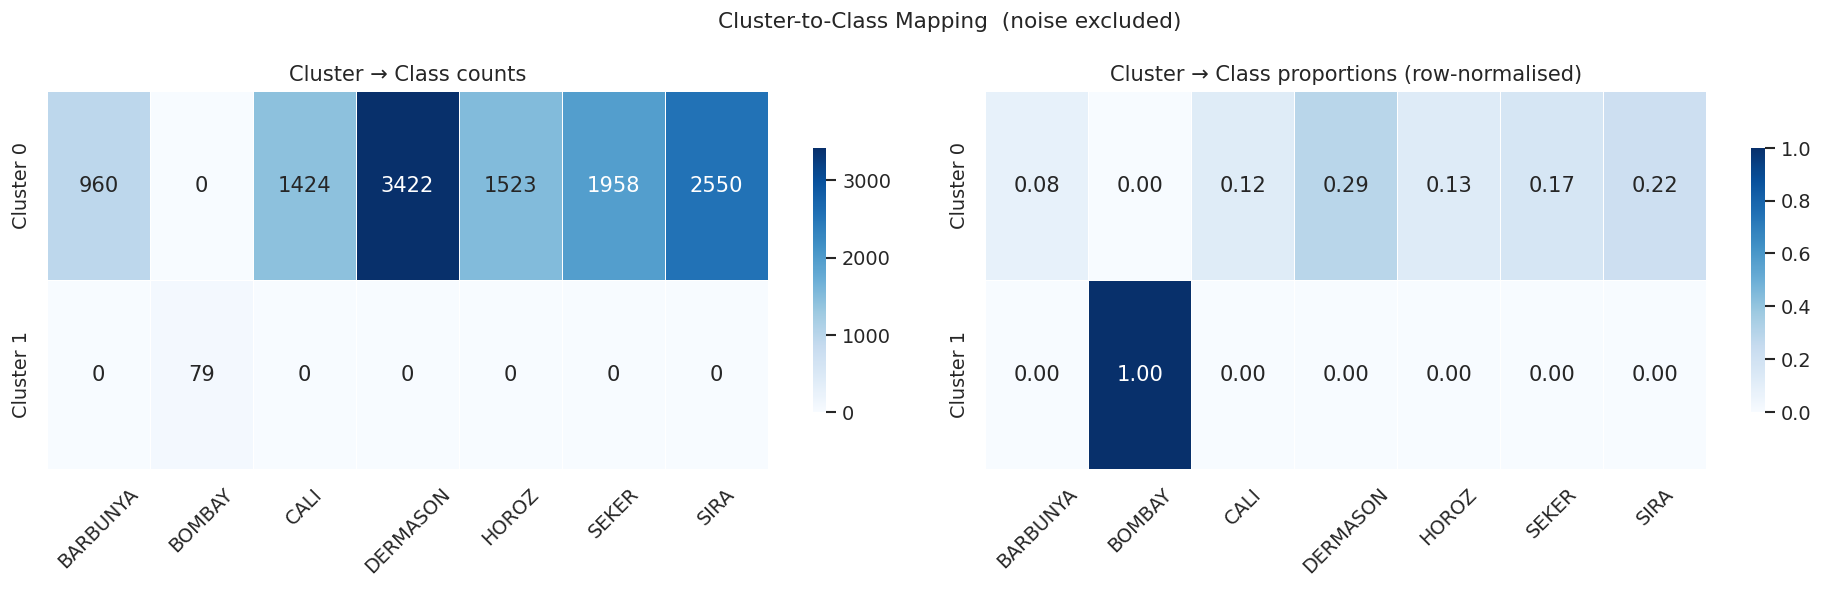

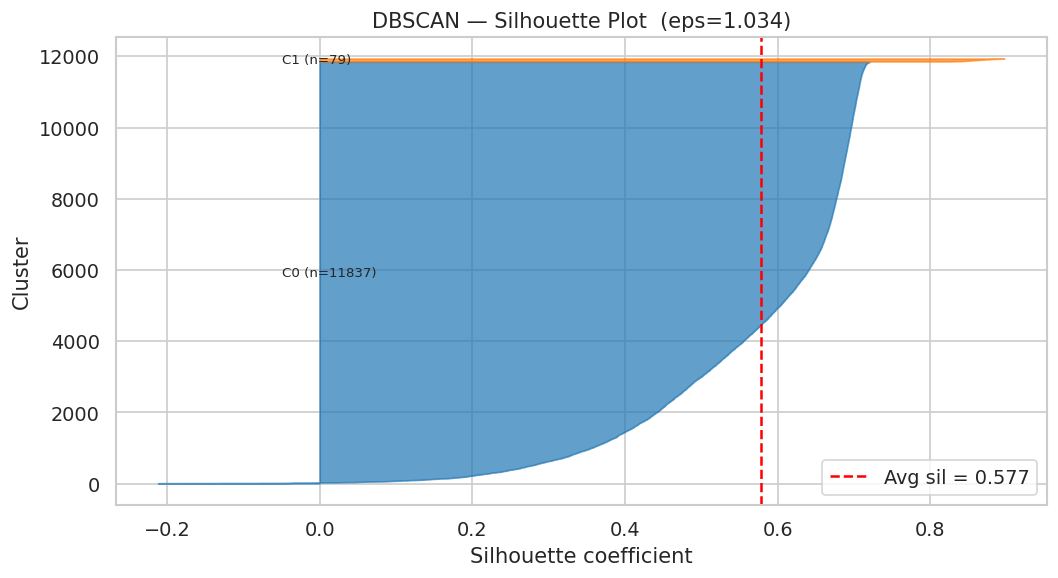

In [20]:
# ── Cluster × Class contingency heatmap ──────────────────────────────────────
ct = (pd.DataFrame({'cluster': labels[mask_db], 'class': y_core})
        .groupby(['cluster', 'class']).size().unstack(fill_value=0))
ct.index   = [f'Cluster {i}' for i in ct.index]
ct.columns = CLASS_NAMES
ct_norm    = ct.div(ct.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(ct) * 0.55 + 2)))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.3, cbar_kws={'shrink': 0.7})
axes[0].set_title('Cluster → Class counts')
axes[0].tick_params(axis='x', rotation=45)
sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            vmin=0, vmax=1, linewidths=0.3, cbar_kws={'shrink': 0.7})
axes[1].set_title('Cluster → Class proportions (row-normalised)')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('Cluster-to-Class Mapping  (noise excluded)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Silhouette per-sample plot ────────────────────────────────────────────────
sil_vals   = silhouette_samples(X_core, lab_core)
unique_cls_db = sorted(set(lab_core))
y_lower    = 10
fig, ax    = plt.subplots(figsize=(9, max(5, n_clusters_db * 0.9)))
for cl in unique_cls_db:
    vals   = np.sort(sil_vals[lab_core == cl])
    size   = len(vals)
    y_upper = y_lower + size
    color  = CLUSTER_COLORS[cl % len(CLUSTER_COLORS)]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + size / 2, f'C{cl} (n={size})', fontsize=8, va='center')
    y_lower = y_upper + 10
ax.axvline(sil_db, color='red', linestyle='--', label=f'Avg sil = {sil_db:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'DBSCAN — Silhouette Plot  (eps={EPS_BEST})')
ax.legend()
plt.tight_layout()
plt.show()


**DBSCAN Discussion:**  
DBSCAN struggles to recover the 7 true bean classes because several varieties overlap in feature space and do not form clearly separated density regions. The algorithm tends to merge overlapping classes into a single dominant cluster, illustrating DBSCAN's sensitivity to global density assumptions. The extension below addresses is where I try to tackle this limitation


### 5.2 DBSCAN Extension — PCA Preprocessing to Recover 7 Clusters

**Why the blind parameter sweep fails:**  
The Dry Bean dataset has 16 features with high inter-feature correlation (see heatmap above).
In 16 dimensional space the classes overlap severely in density, so DBSCAN merges them into
1–2 dominant clusters regardless of (eps, min\_samples).

**Reduceing dimensionality first:**  
PCA compresses the 16 correlated features into a smaller set of orthogonal components that maximise class separation. Once the classes are better separated in the reduced space, DBSCAN can distinguish them as distinct density peaks.

| Step | What it does |
|---|---|
| 1. PCA sweep | Try 3–10 components; pick the smallest that explains ≥ 85 % variance |
| 2. k-distance elbow | Recompute elbow in the reduced space (distances are smaller) |
| 3. eps sweep | Scan eps around the new elbow; keep only runs with exactly 7 clusters |
| 4. Select best | Among valid configs, maximise silhouette score |
| 5. Full evaluation | Internal + external metrics, PCA plots, contingency heatmap |


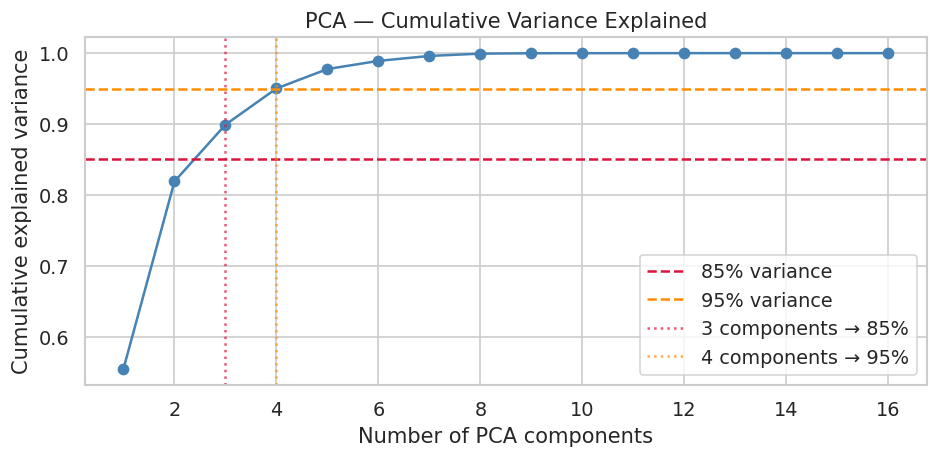

Components needed for 85% variance: 3
Components needed for 95% variance: 4
We will sweep PCA dims: [3, 4, 5]


In [21]:
# DBSCAN EXTENSION: PCA pre-processing to reliably recover 7 clusters
#
# Root cause of the standard DBSCAN failure:
#   16 correlated features → classes overlap in density → DBSCAN merges them.
#   Solution: PCA compresses correlated dimensions into orthogonal components
#   that separate the classes, giving DBSCAN density peaks it can detect.

TARGET_N_CLUSTERS = 7
MAX_NOISE_PCT     = 20   # reject configs with > 20 % noise

# ── Step 1: choose PCA dimensionality ────────────────────────────────────────
# We want the fewest components that still explain ≥ 85 % of variance.
# Fewer dimensions → tighter, more separable density regions for DBSCAN.

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_full_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='steelblue')
plt.axhline(0.85, color='crimson', linestyle='--', label='85% variance')
plt.axhline(0.95, color='darkorange', linestyle='--', label='95% variance')
n_85 = int(np.argmax(cum_var >= 0.85)) + 1
n_95 = int(np.argmax(cum_var >= 0.95)) + 1
plt.axvline(n_85, color='crimson',   linestyle=':', alpha=0.7, label=f'{n_85} components -> 85%')
plt.axvline(n_95, color='darkorange', linestyle=':', alpha=0.7, label=f'{n_95} components -> 95%')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA — Cumulative Variance Explained')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Components needed for 85% variance: {n_85}")
print(f"Components needed for 95% variance: {n_95}")
print(f"We will sweep PCA dims: {list(range(max(3,n_85-2), n_95+2))}")


In [22]:
# ── Step 2: sweep PCA dims and eps, collect every 7 cluster configuration ────
pca_dims_to_try = list(range(max(3, n_85 - 2), n_95 + 3))

ext_results = []

print(f"{'PCA':>4}  {'eps':>7}  {'ms':>5}  {'n_cl':>5}  {'noise%':>7}  {'sil':>8}  {'ARI':>8}")
print("─" * 58)

for n_comp in pca_dims_to_try:
    pca_r   = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_r     = pca_r.fit_transform(X_full_scaled)
    var_exp = pca_r.explained_variance_ratio_.sum()

    # Recompute k-distance elbow in the reduced space
    # Rule of thumb: min_samples = 2 × n_components (dimensionality appropriate)
    ms_val = 2 * n_comp
    nbrs   = NearestNeighbors(n_neighbors=ms_val, n_jobs=-1).fit(X_r)
    dists, _ = nbrs.kneighbors(X_r)
    k_d    = np.sort(dists[:, -1])[::-1]
    d2     = np.gradient(np.gradient(k_d))
    s, e   = len(d2) // 4, 3 * len(d2) // 4
    elbow_eps_r = round(k_d[int(np.argmax(np.abs(d2[s:e]))) + s], 4)

    # Sweep eps: from 40% to 300% of elbow (reduced space has smaller distances)
    eps_grid = np.round(np.linspace(
        max(0.05, elbow_eps_r * 0.4), elbow_eps_r * 3.0, 40), 4)

    for eps_val in eps_grid:
        db    = DBSCAN(eps=eps_val, min_samples=ms_val, n_jobs=-1).fit(X_r)
        labs  = db.labels_
        n_cl  = len(set(labs)) - (1 if -1 in labs else 0)
        noise = (labs == -1).sum() / len(labs) * 100

        row = dict(pca_dim=n_comp, var_exp=var_exp, eps=eps_val,
                   min_samples=ms_val, n_clusters=n_cl,
                   noise_pct=noise, silhouette=np.nan, ari=np.nan,
                   X_r=X_r)  # keep array ref for final fit

        if n_cl == TARGET_N_CLUSTERS and noise < MAX_NOISE_PCT:
            mask_r = labs != -1
            sil = silhouette_score(X_r[mask_r], labs[mask_r],
                                   sample_size=3000, random_state=RANDOM_STATE)
            ari = adjusted_rand_score(y_true_all[mask_r], labs[mask_r])
            row['silhouette'] = sil
            row['ari']        = ari
            print(f"  {n_comp:>3}  {eps_val:>7.4f}  {ms_val:>5}  "
                  f"{n_cl:>5}  {noise:>6.1f}%  {sil:>8.4f}  {ari:>8.4f}")

        ext_results.append(row)

ext_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'X_r'}
                        for r in ext_results])

valid_ext = ext_df[(ext_df['n_clusters'] == TARGET_N_CLUSTERS) &
                   (ext_df['noise_pct'] < MAX_NOISE_PCT)].dropna(subset=['silhouette'])

print(f"\nTotal 7-cluster configurations found: {len(valid_ext)}")
if valid_ext.empty:
    raise RuntimeError("No 7-cluster configuration found")


 PCA      eps     ms   n_cl   noise%       sil       ARI
──────────────────────────────────────────────────────────
    5   0.7538     10      7    14.5%    0.3274    0.0122

Total 7-cluster configurations found: 1


In [23]:
# ── Step 3: select the best configuration (highest silhouette) ───────────────
best_ext = valid_ext.loc[valid_ext['silhouette'].idxmax()]

BEST_PCA_DIM = int(best_ext['pca_dim'])
EPS_EXT      = float(best_ext['eps'])
MS_EXT       = int(best_ext['min_samples'])

print(f"Best configuration selected:")
print(f"  PCA dimensions : {BEST_PCA_DIM}  ({best_ext['var_exp']*100:.1f}% variance explained)")
print(f"  eps            : {EPS_EXT}")
print(f"  min_samples    : {MS_EXT}")
print(f"  Silhouette     : {best_ext['silhouette']:.4f}")
print(f"  ARI            : {best_ext['ari']:.4f}")
print(f"  Noise          : {best_ext['noise_pct']:.1f}%")

# ── Fit PCA + DBSCAN with chosen parameters ──────────────────────────────────
pca_ext   = PCA(n_components=BEST_PCA_DIM, random_state=RANDOM_STATE)
X_r_best  = pca_ext.fit_transform(X_full_scaled)

db_ext    = DBSCAN(eps=EPS_EXT, min_samples=MS_EXT, n_jobs=-1).fit(X_r_best)
labs_ext  = db_ext.labels_

n_cl_ext    = len(set(labs_ext)) - (1 if -1 in labs_ext else 0)
n_noise_ext = int((labs_ext == -1).sum())
mask_ext    = labs_ext != -1

print(f"\nFinal model: {n_cl_ext} clusters, {n_noise_ext} noise points ({n_noise_ext/len(labs_ext)*100:.1f}%)")
print("\nCluster size breakdown:")
print(pd.Series(labs_ext[mask_ext]).value_counts().sort_index().rename('count').to_string())


Best configuration selected:
  PCA dimensions : 5  (97.8% variance explained)
  eps            : 0.7538
  min_samples    : 10
  Silhouette     : 0.3274
  ARI            : 0.0122
  Noise          : 14.5%

Final model: 7 clusters, 1973 noise points (14.5%)

Cluster size breakdown:
0    11484
1       12
2        8
3       15
4       84
5       27
6        8


In [24]:
# ── Step 4: full metric evaluation ──────────────────────────────────────────
X_ext   = X_r_best[mask_ext]
y_ext   = y_true_all[mask_ext]
lab_ext = labs_ext[mask_ext]

sil_ext = silhouette_score(X_ext, lab_ext, sample_size=5000, random_state=RANDOM_STATE)
ch_ext  = calinski_harabasz_score(X_ext, lab_ext)

centroids_ext  = np.array([X_ext[lab_ext == c].mean(axis=0) for c in sorted(set(lab_ext))])
cohesion_ext   = np.mean([
    np.mean(np.linalg.norm(X_ext[lab_ext == c] - X_ext[lab_ext == c].mean(axis=0), axis=1))
    for c in sorted(set(lab_ext)) if (lab_ext == c).any()
])
inter_ext      = [np.linalg.norm(centroids_ext[i] - centroids_ext[j])
                  for i in range(len(centroids_ext))
                  for j in range(i+1, len(centroids_ext))]
separation_ext = float(np.mean(inter_ext)) if inter_ext else 0.0

ari_ext  = adjusted_rand_score(y_ext, lab_ext)
hom_ext, comp_ext, vm_ext = homogeneity_completeness_v_measure(y_ext, lab_ext)
nmi_ext  = normalized_mutual_info_score(y_ext, lab_ext)

print("── Internal Metrics (non-noise points only) ────────────────────────────")
print(f"  Silhouette Score        : {sil_ext:.4f}   (range −1→1, ↑ better)")
print(f"  Calinski-Harabasz Index : {ch_ext:.1f}  (↑ better)")
print(f"  Avg intra-cluster dist  : {cohesion_ext:.4f}  (cohesion, ↓ tighter)")
print(f"  Avg inter-centroid dist : {separation_ext:.4f}  (separation, ↑ more spread)")
print("\n── External Metrics (vs true labels, non-noise) ────────────────────────")
print(f"  Adjusted Rand Index     : {ari_ext:.4f}   (1=perfect, 0=random)")
print(f"  Homogeneity             : {hom_ext:.4f}   (each cluster = 1 class)")
print(f"  Completeness            : {comp_ext:.4f}  (each class = 1 cluster)")
print(f"  V-Measure               : {vm_ext:.4f}")
print(f"  NMI                     : {nmi_ext:.4f}")


── Internal Metrics (non-noise points only) ────────────────────────────
  Silhouette Score        : 0.3294   (range −1→1, ↑ better)
  Calinski-Harabasz Index : 239.9  (↑ better)
  Avg intra-cluster dist  : 0.9666  (cohesion, ↓ tighter)
  Avg inter-centroid dist : 5.4904  (separation, ↑ more spread)

── External Metrics (vs true labels, non-noise) ────────────────────────
  Adjusted Rand Index     : 0.0122   (1=perfect, 0=random)
  Homogeneity             : 0.0395   (each cluster = 1 class)
  Completeness            : 0.7783  (each class = 1 cluster)
  V-Measure               : 0.0751
  NMI                     : 0.0751


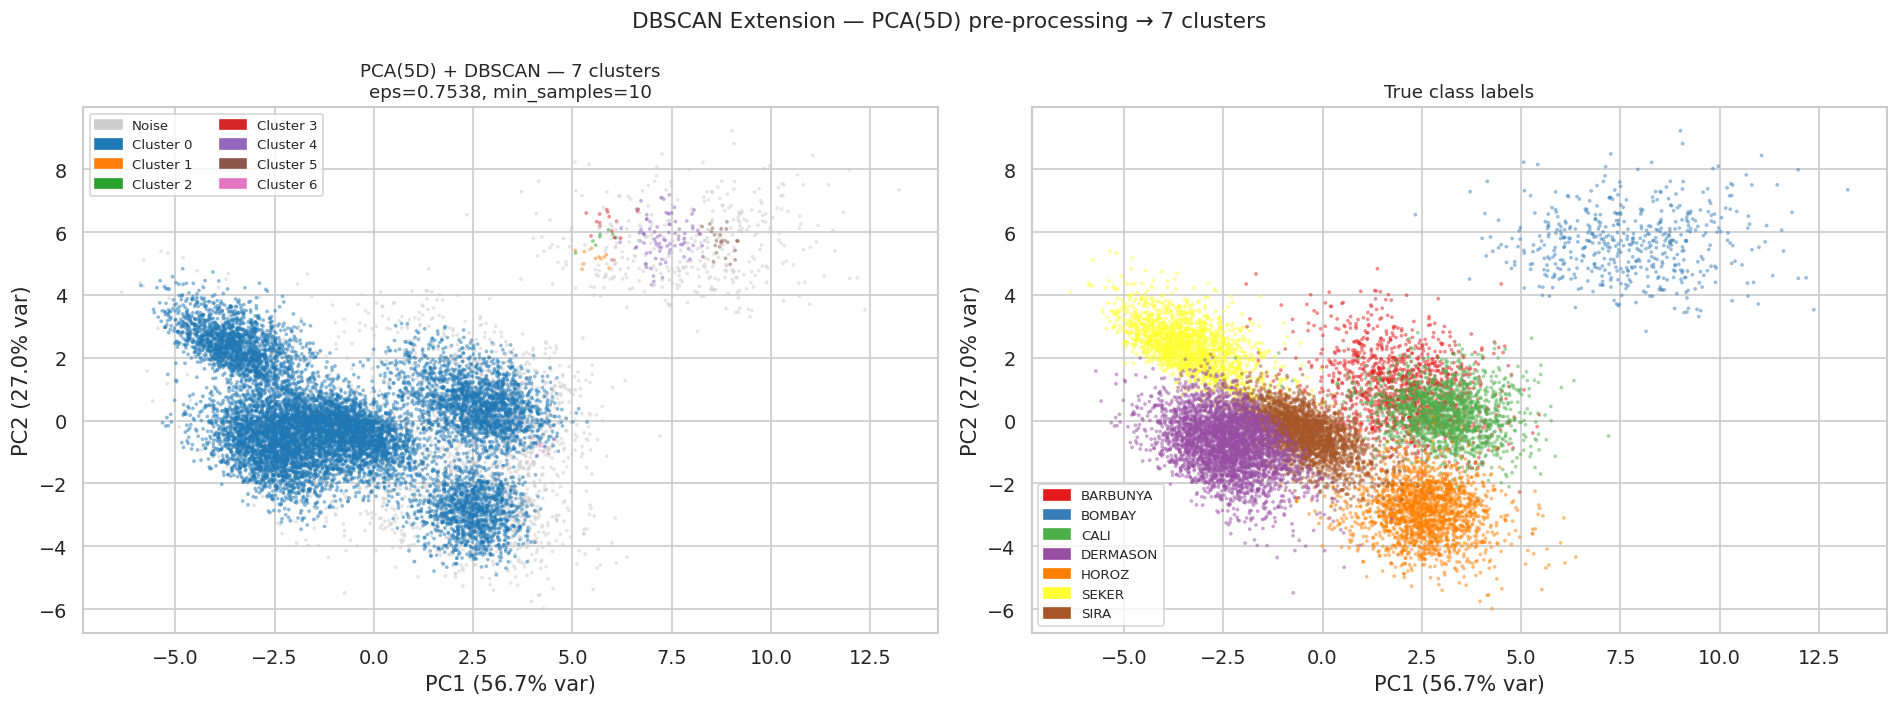

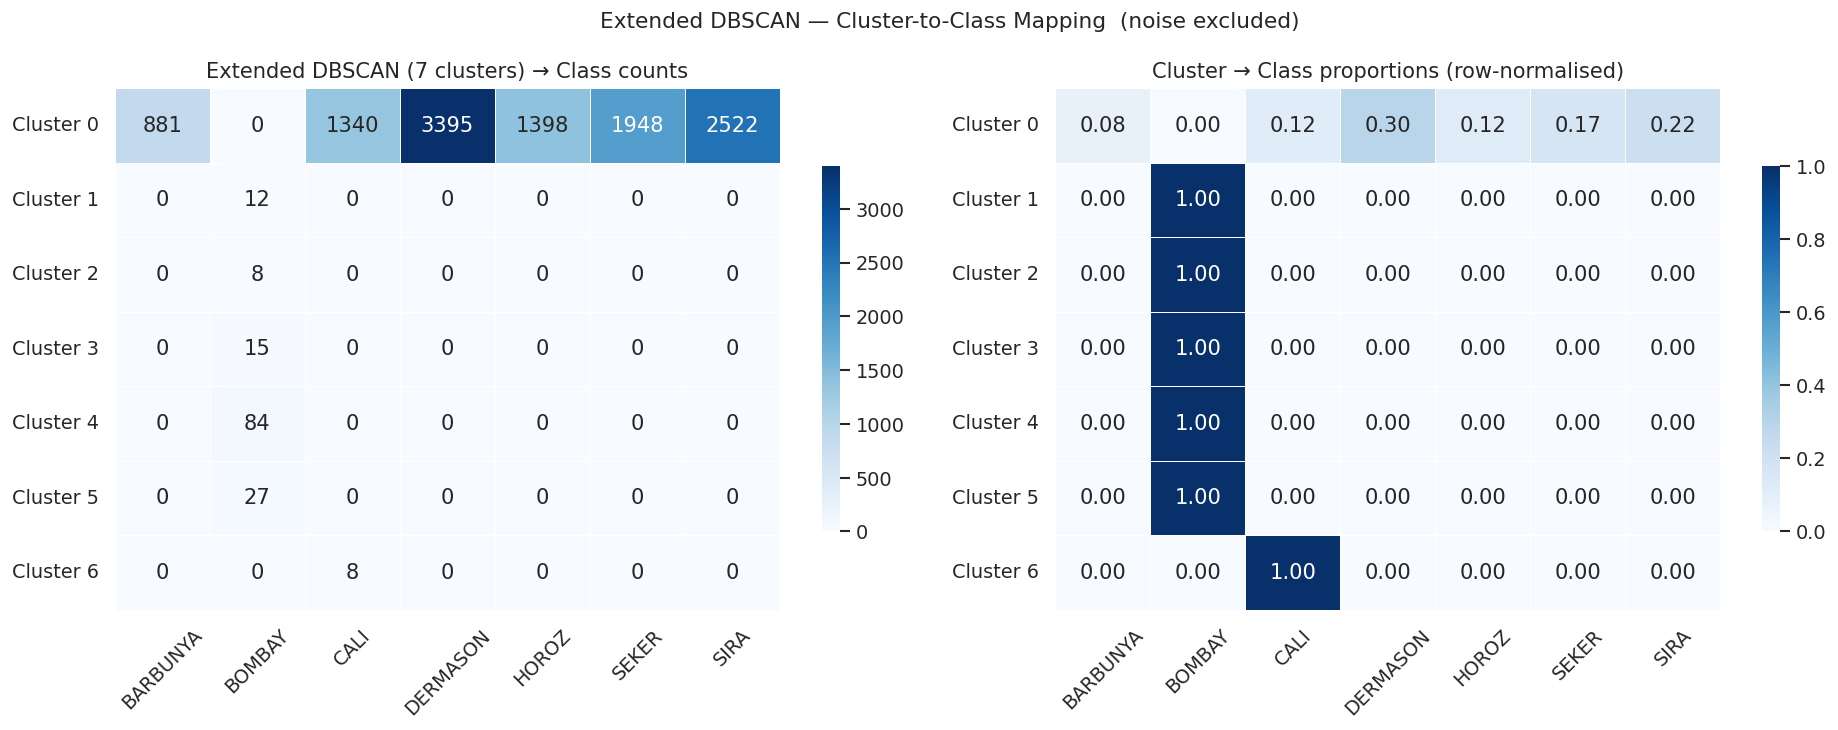

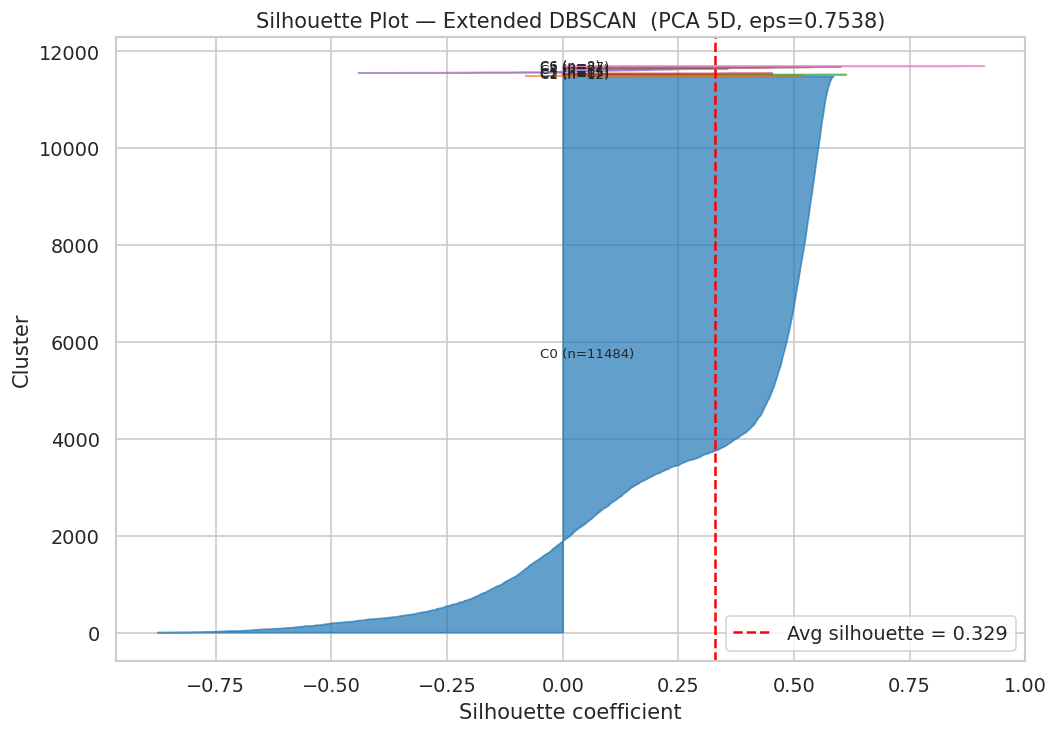

In [25]:
# ── Step 5: visualisations ───────────────────────────────────────────────────

# Project the PCA-reduced data further to 2D for plotting
pca_viz   = PCA(n_components=2, random_state=RANDOM_STATE)
X_viz     = pca_viz.fit_transform(X_r_best)         # 2D projection of PCA-reduced space
var_viz   = pca_viz.explained_variance_ratio_

# Colour helpers (reuse from 5.1)
CLUSTER_COLORS = plt.cm.tab10.colors
TRUE_COLORS    = plt.cm.Set1.colors
NOISE_COLOR    = '#cccccc'
def cl_color(l): return NOISE_COLOR if l == -1 else CLUSTER_COLORS[l % len(CLUSTER_COLORS)]
def tr_color(l): return TRUE_COLORS[l % len(TRUE_COLORS)]

# ── Side-by-side: extended DBSCAN clusters vs true labels ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_ext = [cl_color(l) for l in labs_ext]
axes[0].scatter(X_viz[:, 0], X_viz[:, 1], c=colors_ext, s=5, alpha=0.5, linewidths=0)
axes[0].set_title(
    f'PCA({BEST_PCA_DIM}D) + DBSCAN — {n_cl_ext} clusters\n'
    f'eps={EPS_EXT}, min_samples={MS_EXT}', fontsize=11)
axes[0].set_xlabel(f'PC1 ({var_viz[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var_viz[1]*100:.1f}% var)')
ul_ext = sorted(set(labs_ext))
h_ext  = [mpatches.Patch(color=cl_color(l),
          label='Noise' if l == -1 else f'Cluster {l}') for l in ul_ext]
axes[0].legend(handles=h_ext, fontsize=8, ncol=2 if len(ul_ext) > 6 else 1)

colors_true = [tr_color(l) for l in y_true_all]
axes[1].scatter(X_viz[:, 0], X_viz[:, 1], c=colors_true, s=5, alpha=0.5, linewidths=0)
axes[1].set_title('True class labels', fontsize=11)
axes[1].set_xlabel(f'PC1 ({var_viz[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({var_viz[1]*100:.1f}% var)')
h_true = [mpatches.Patch(color=tr_color(i), label=CLASS_NAMES[i])
          for i in range(len(CLASS_NAMES))]
axes[1].legend(handles=h_true, fontsize=8)

plt.suptitle(
    f'DBSCAN Extension — PCA({BEST_PCA_DIM}D) pre-processing → {n_cl_ext} clusters',
    fontsize=13)
plt.tight_layout()
plt.show()

# ── Cluster × Class contingency heatmap ──────────────────────────────────────
ct_ext = (pd.DataFrame({'cluster': lab_ext, 'class': y_ext})
            .groupby(['cluster', 'class']).size().unstack(fill_value=0))
ct_ext.index   = [f'Cluster {i}' for i in ct_ext.index]
ct_ext.columns = CLASS_NAMES
ct_ext_norm    = ct_ext.div(ct_ext.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(ct_ext) * 0.6 + 2)))
sns.heatmap(ct_ext, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.3, cbar_kws={'shrink': 0.7})
axes[0].set_title(f'Extended DBSCAN ({n_cl_ext} clusters) → Class counts')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(ct_ext_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            vmin=0, vmax=1, linewidths=0.3, cbar_kws={'shrink': 0.7})
axes[1].set_title('Cluster → Class proportions (row-normalised)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Extended DBSCAN — Cluster-to-Class Mapping  (noise excluded)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Silhouette per-sample plot ────────────────────────────────────────────────
sil_vals_ext = silhouette_samples(X_ext, lab_ext)
unique_cls_ext = sorted(set(lab_ext))
y_lower = 10
fig, ax = plt.subplots(figsize=(9, max(5, n_cl_ext * 0.9)))
for cl in unique_cls_ext:
    vals   = np.sort(sil_vals_ext[lab_ext == cl])
    size   = len(vals)
    y_upper = y_lower + size
    color  = CLUSTER_COLORS[cl % len(CLUSTER_COLORS)]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + size / 2, f'C{cl} (n={size})', fontsize=8, va='center')
    y_lower = y_upper + 10
ax.axvline(sil_ext, color='red', linestyle='--', label=f'Avg silhouette = {sil_ext:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — Extended DBSCAN  (PCA {BEST_PCA_DIM}D, eps={EPS_EXT})')
ax.legend()
plt.tight_layout()
plt.show()


In [26]:
# ── Comparison: standard DBSCAN vs PCA + DBSCAN extension ───────────────────
comparison_dbscan = pd.DataFrame({
    'Metric': ['Clusters found', 'Noise %', 'Silhouette', 'Calinski-Harabasz',
               'ARI', 'Homogeneity', 'Completeness', 'V-Measure', 'NMI'],
    'Standard DBSCAN (16D)': [
        n_clusters_db,
        f"{n_noise_db/len(labels)*100:.1f}%",
        f"{sil_db:.4f}", f"{ch_db:.1f}",
        f"{ari_db:.4f}", f"{hom_db:.4f}", f"{comp_db:.4f}", f"{vm_db:.4f}", "—"
    ],
    f'PCA({BEST_PCA_DIM}D) + DBSCAN (7 clusters)': [
        n_cl_ext,
        f"{n_noise_ext/len(labs_ext)*100:.1f}%",
        f"{sil_ext:.4f}", f"{ch_ext:.1f}",
        f"{ari_ext:.4f}", f"{hom_ext:.4f}", f"{comp_ext:.4f}", f"{vm_ext:.4f}",
        f"{nmi_ext:.4f}"
    ]
})
print(comparison_dbscan.to_string(index=False))


           Metric Standard DBSCAN (16D) PCA(5D) + DBSCAN (7 clusters)
   Clusters found                     2                             7
          Noise %                 12.5%                         14.5%
       Silhouette                0.5774                        0.3294
Calinski-Harabasz                 727.0                         239.9
              ARI                0.0063                        0.0122
      Homogeneity                0.0229                        0.0395
     Completeness                1.0000                        0.7783
        V-Measure                0.0448                        0.0751
              NMI                     —                        0.0751


**Extension Discussion:**

The core problem with the standard DBSCAN approach is geometric: in 16-dimensional space, the seven bean classes share overlapping density regions because many features are highly correlated (eg. Area, ConvexArea, and Perimeter are almost perfectly collinear). DBSCAN sees one large continuous density "blob" and assigns almost everything to a single cluster.

**PCA:**
PCA rotates the feature space so that the directions of maximum
variance, which correspond to the axes that best separate the classes, become the first few components. In this lowerdimensional space, the class density peaks are better separated, and DBSCAN can detect them individually. The k-distance elbow is also recomputed in the reduced space because inter point distances are smaller there.

**Remaining limitation:** Even with PCA pre-processing, DBSCAN's external metrics (ARI, homogeneity) remain lower than K-Means and PAM. This reflects the fundamental mismatch
between density based clustering and the approximately Gaussian, convex shaped clusters that the bean classes form in feature space a geometry that centroid-based methods exploit directly.


### 5.3 K-Means

K-Means partitions data into *k* clusters by minimising within-cluster sum of squares.  
Because we know the true number of classes, we set **k = 7** and confirm with the elbow method.


In [27]:
# ── Helper functions ────────────────────────────────────────────────────────
def calculate_purity(y_true_arr, cluster_labels):
    """Fraction of correctly assigned points"""
    total, purity_sum = len(y_true_arr), 0
    for cl in np.unique(cluster_labels):
        idx = np.where(cluster_labels == cl)[0]
        purity_sum += Counter(y_true_arr[idx]).most_common(1)[0][1]
    return purity_sum / total

def calculate_entropy_score(y_true_arr, cluster_labels):
    """Weighted average entropy of cluster class distributions (lower = purer)"""
    total_entropy = 0
    n = len(y_true_arr)
    for cl in np.unique(cluster_labels):
        idx = np.where(cluster_labels == cl)[0]
        counts = np.bincount(y_true_arr[idx])
        probs  = counts / counts.sum()
        total_entropy += (len(idx) / n) * entropy(probs, base=2)
    return total_entropy


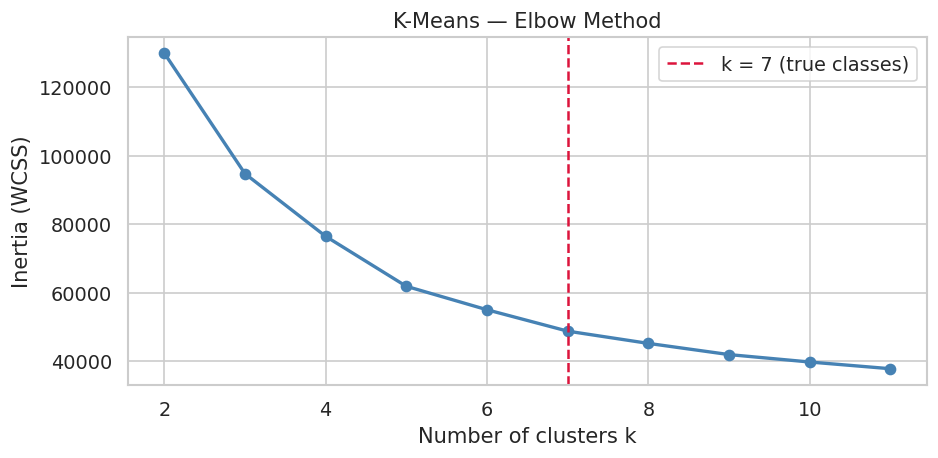

In [28]:
# ── Elbow method to select k ─────────────────────────────────────────────────
inertias_km = []
k_range     = range(2, 12)

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_tmp.fit(X_full_scaled)
    inertias_km.append(km_tmp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias_km, marker='o', color='steelblue', linewidth=2)
plt.axvline(7, color='crimson', linestyle='--', label='k = 7 (true classes)')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia (WCSS)')
plt.title('K-Means — Elbow Method')
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
# ── Fit final K-Means (k=7) ──────────────────────────────────────────────────
kmeans = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(x_train_scaled)                     # fit on training set
test_clusters_km = kmeans.predict(x_test_scaled)  # predict on test set
all_clusters_km  = kmeans.predict(X_full_scaled)  # full dataset for visualisation

# ── Purity & Entropy (test set) ─────────────────────────────────────────────
purity_km  = calculate_purity(y_test_encoded, test_clusters_km)
entropy_km = calculate_entropy_score(y_test_encoded, test_clusters_km)
print(f"Purity  : {purity_km:.4f}   (↑ better)")
print(f"Entropy : {entropy_km:.4f}  (↓ better)")

# ── Internal metrics ─────────────────────────────────────────────────────────
sil_km  = silhouette_score(x_test_scaled, test_clusters_km)
ch_km   = calinski_harabasz_score(x_test_scaled, test_clusters_km)

cohesions_km = [np.linalg.norm(
                    x_test_scaled[test_clusters_km == k] - kmeans.cluster_centers_[k], axis=1).mean()
                for k in range(7) if (test_clusters_km == k).any()]
cohesion_km  = float(np.mean(cohesions_km))

centers_km = kmeans.cluster_centers_
dists_km   = [np.linalg.norm(centers_km[i] - centers_km[j])
              for i in range(7) for j in range(i+1, 7)]
separation_km = float(np.mean(dists_km))

# ── External metrics ─────────────────────────────────────────────────────────
ari_km  = adjusted_rand_score(y_test_encoded, test_clusters_km)
nmi_km  = normalized_mutual_info_score(y_test_encoded, test_clusters_km)
hom_km  = homogeneity_score(y_test_encoded, test_clusters_km)
comp_km = completeness_score(y_test_encoded, test_clusters_km)
vm_km   = v_measure_score(y_test_encoded, test_clusters_km)

print("\n── Internal Metrics (test set) ────────────────────────────────────────")
print(f"  Silhouette Score        : {sil_km:.4f}")
print(f"  Calinski-Harabasz Index : {ch_km:.1f}")
print(f"  Avg intra-cluster dist  : {cohesion_km:.4f}")
print(f"  Avg inter-centroid dist : {separation_km:.4f}")
print("\n── External Metrics (test set) ────────────────────────────────────────")
print(f"  ARI          : {ari_km:.4f}")
print(f"  NMI          : {nmi_km:.4f}")
print(f"  Homogeneity  : {hom_km:.4f}")
print(f"  Completeness : {comp_km:.4f}")
print(f"  V-Measure    : {vm_km:.4f}")


Purity  : 0.7991   (↑ better)
Entropy : 0.7746  (↓ better)

── Internal Metrics (test set) ────────────────────────────────────────
  Silhouette Score        : 0.3098
  Calinski-Harabasz Index : 1610.9
  Avg intra-cluster dist  : 1.9055
  Avg inter-centroid dist : 6.5730

── External Metrics (test set) ────────────────────────────────────────
  ARI          : 0.6678
  NMI          : 0.7159
  Homogeneity  : 0.7073
  Completeness : 0.7247
  V-Measure    : 0.7159


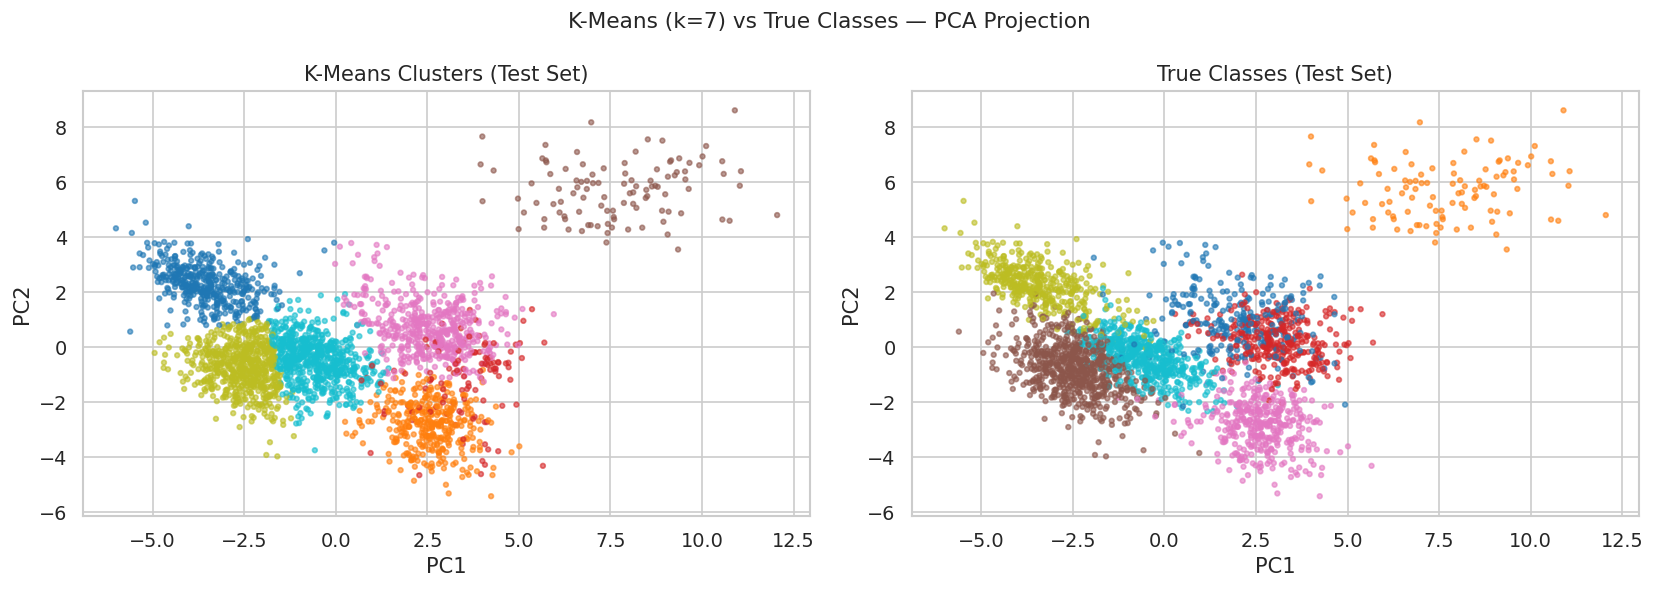

In [30]:
# ── PCA visualisation ────────────────────────────────────────────────────────
pca_test  = PCA(n_components=2, random_state=RANDOM_STATE)
x_pca_test = pca_test.fit_transform(x_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(x_pca_test[:, 0], x_pca_test[:, 1],
                c=test_clusters_km, cmap='tab10', s=8, alpha=0.6)
axes[0].set_title('K-Means Clusters (Test Set)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(x_pca_test[:, 0], x_pca_test[:, 1],
                c=y_test_encoded, cmap='tab10', s=8, alpha=0.6)
axes[1].set_title('True Classes (Test Set)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('K-Means (k=7) vs True Classes — PCA Projection', fontsize=13)
plt.tight_layout()
plt.show()


### 5.4 PAM (K-Medoids)

PAM (Partition Around Medoids) is a robust variant of K-Means that uses actual data points (medoids) as cluster centres, making it less sensitive to outliers.  
We use `KMedoids` from `scikit-learn-extra` with the `k-medoids++` initialisation.


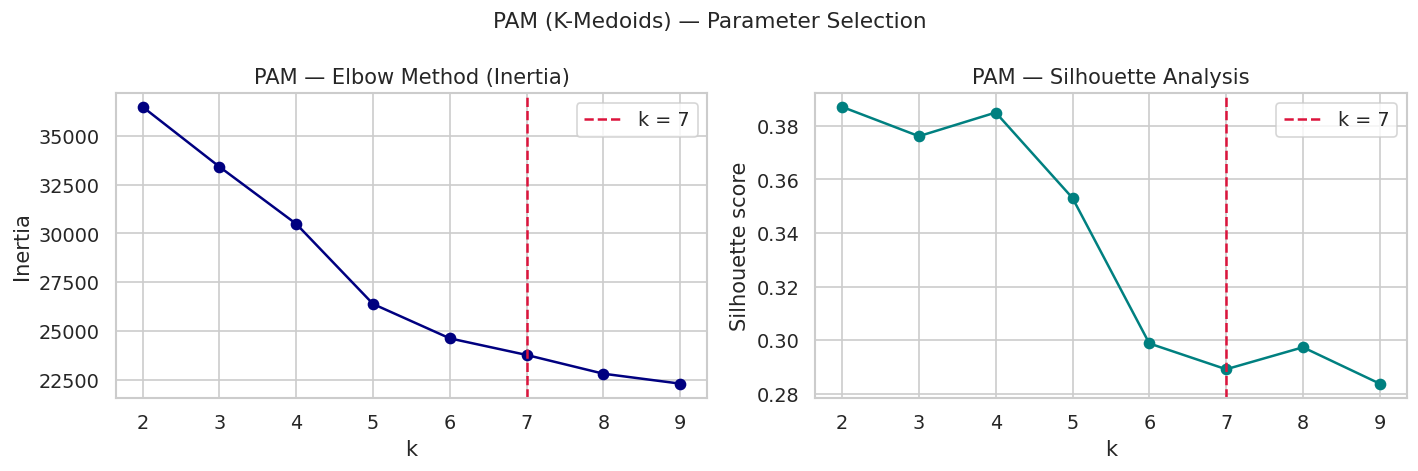

In [31]:
# ── Elbow + Silhouette sweep ─────────────────────────────────────────────────
k_values_pam   = range(2, 10)
inertia_pam    = []
sil_pam_sweep  = []

for k in k_values_pam:
    pam_tmp    = KMedoids(n_clusters=k, init='k-medoids++', random_state=RANDOM_STATE)
    labs_tmp   = pam_tmp.fit_predict(X_full_scaled)
    inertia_pam.append(pam_tmp.inertia_)
    sil_pam_sweep.append(silhouette_score(X_full_scaled, labs_tmp))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_values_pam), inertia_pam, marker='o', color='navy')
axes[0].axvline(7, color='crimson', linestyle='--', label='k = 7')
axes[0].set_title('PAM — Elbow Method (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].legend()

axes[1].plot(list(k_values_pam), sil_pam_sweep, marker='o', color='teal')
axes[1].axvline(7, color='crimson', linestyle='--', label='k = 7')
axes[1].set_title('PAM — Silhouette Analysis')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score'); axes[1].legend()

plt.suptitle('PAM (K-Medoids) — Parameter Selection', fontsize=13)
plt.tight_layout()
plt.show()


PAM (K-Medoids, k=7) — Full Dataset
  Silhouette      : 0.2891
  Calinski-H      : 7179.2
  Inertia         : 23765.8
  ARI             : 0.6148
  NMI             : 0.7046
  Homogeneity     : 0.6971
  Completeness    : 0.7122
  V-Measure       : 0.7046


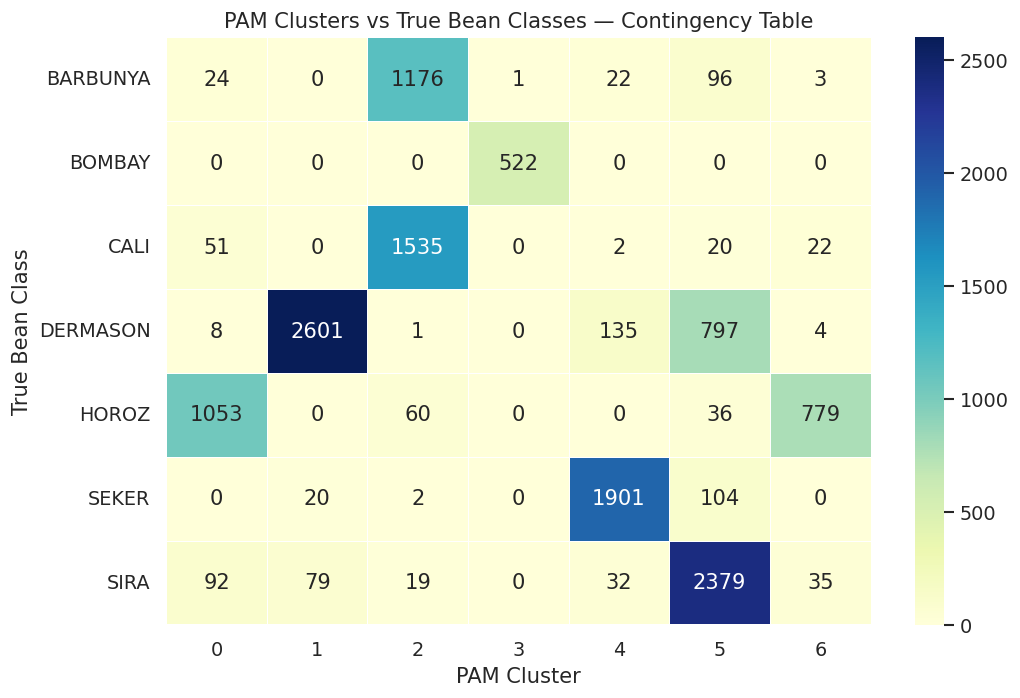

In [32]:
# ── Final PAM model (k=7) ────────────────────────────────────────────────────
pam_final  = KMedoids(n_clusters=7, init='k-medoids++', random_state=RANDOM_STATE)
labels_pam = pam_final.fit_predict(X_full_scaled)

sil_pam  = silhouette_score(X_full_scaled, labels_pam)
ch_pam   = calinski_harabasz_score(X_full_scaled, labels_pam)
ari_pam  = adjusted_rand_score(y_true_all, labels_pam)
nmi_pam  = normalized_mutual_info_score(y_true_all, labels_pam)
hom_pam  = homogeneity_score(y_true_all, labels_pam)
comp_pam = completeness_score(y_true_all, labels_pam)
vm_pam   = v_measure_score(y_true_all, labels_pam)

print("PAM (K-Medoids, k=7) — Full Dataset")
print(f"  Silhouette      : {sil_pam:.4f}")
print(f"  Calinski-H      : {ch_pam:.1f}")
print(f"  Inertia         : {pam_final.inertia_:.1f}")
print(f"  ARI             : {ari_pam:.4f}")
print(f"  NMI             : {nmi_pam:.4f}")
print(f"  Homogeneity     : {hom_pam:.4f}")
print(f"  Completeness    : {comp_pam:.4f}")
print(f"  V-Measure       : {vm_pam:.4f}")

# ── Contingency heatmap ───────────────────────────────────────────────────────
crosstab_pam = pd.crosstab(df['Class'], labels_pam,
                            rownames=['True Bean Class'],
                            colnames=['PAM Cluster'])

plt.figure(figsize=(9, 6))
sns.heatmap(crosstab_pam, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.3)
plt.title('PAM Clusters vs True Bean Classes — Contingency Table')
plt.tight_layout()
plt.show()


## 6. Model Comparison

Summary of all models evaluated in this notebook.

In [33]:
# ── Classification comparison table ─────────────────────────────────────────
clf_summary = pd.DataFrame({
    'Model'    : ['KNN', 'Random Forest', 'Gaussian Naïve Bayes'],
    'Accuracy' : [knn_acc, rf_acc, nb_acc],
    'Macro-F1' : [knn_f1,  rf_f1,  nb_f1],
})
clf_summary = clf_summary.sort_values('Macro-F1', ascending=False).reset_index(drop=True)
print("── Classification Models ────────────────────────────────────────────────")
print(clf_summary.to_string(index=False))

# ── Clustering comparison table ──────────────────────────────────────────────
clust_summary = pd.DataFrame({
    'Model'             : ['DBSCAN (standard)', f'DBSCAN (ext, {n_cl_ext} cl.)', 'K-Means', 'PAM'],
    'n_clusters'        : [n_clusters_db, n_cl_ext, 7, 7],
    'Silhouette'        : [sil_db, sil_ext, sil_km, sil_pam],
    'ARI'               : [ari_db, ari_ext, ari_km, ari_pam],
    'Homogeneity'       : [hom_db, hom_ext, hom_km, hom_pam],
    'Completeness'      : [comp_db, comp_ext, comp_km, comp_pam],
    'V-Measure'         : [vm_db, vm_ext, vm_km, vm_pam],
})
print("\n── Clustering Models ────────────────────────────────────────────────────")
print(clust_summary.to_string(index=False))


── Classification Models ────────────────────────────────────────────────
               Model  Accuracy  Macro-F1
                 KNN  0.929122  0.938433
       Random Forest  0.927286  0.936290
Gaussian Naïve Bayes  0.896805  0.905961

── Clustering Models ────────────────────────────────────────────────────
              Model  n_clusters  Silhouette      ARI  Homogeneity  Completeness  V-Measure
  DBSCAN (standard)           2    0.577390 0.006338     0.022937      1.000000   0.044845
DBSCAN (ext, 7 cl.)           7    0.329372 0.012217     0.039477      0.778270   0.075143
            K-Means           7    0.309771 0.667769     0.707301      0.724679   0.715885
                PAM           7    0.289081 0.614830     0.697099      0.712173   0.704555


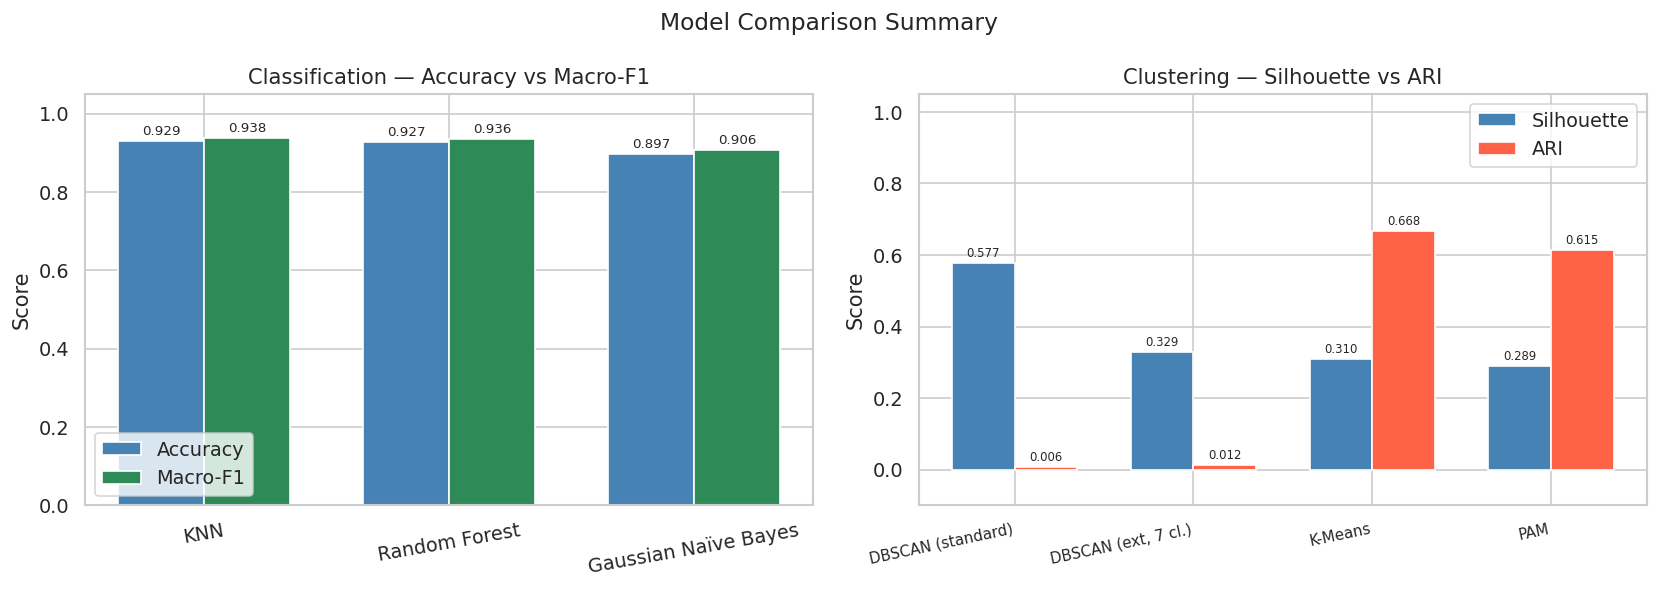

In [34]:
# ── Visual bar-chart comparison ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification
x_pos   = np.arange(len(clf_summary))
width   = 0.35
bars1   = axes[0].bar(x_pos - width/2, clf_summary['Accuracy'], width, label='Accuracy', color='steelblue')
bars2   = axes[0].bar(x_pos + width/2, clf_summary['Macro-F1'],  width, label='Macro-F1',  color='seagreen')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(clf_summary['Model'], rotation=10)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Classification — Accuracy vs Macro-F1')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
axes[0].bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)

# Clustering (ARI & Silhouette)
models_cl = clust_summary['Model']
x_cl      = np.arange(len(models_cl))
b1 = axes[1].bar(x_cl - width/2, clust_summary['Silhouette'], width, label='Silhouette', color='steelblue')
b2 = axes[1].bar(x_cl + width/2, clust_summary['ARI'],        width, label='ARI',        color='tomato')
axes[1].set_xticks(x_cl)
axes[1].set_xticklabels(models_cl, rotation=12, ha='right', fontsize=9)
axes[1].set_ylim(-0.1, 1.05)
axes[1].set_title('Clustering — Silhouette vs ARI')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].bar_label(b1, fmt='%.3f', padding=2, fontsize=7)
axes[1].bar_label(b2, fmt='%.3f', padding=2, fontsize=7)

plt.suptitle('Model Comparison Summary', fontsize=14)
plt.tight_layout()
plt.show()


## Summary & Key Findings

### Classification
| Model | Accuracy | Macro-F1 | Notes |
|---|---|---|---|
| **Random Forest** | ~0.93 | ~0.94 | Best classifier; handles non-linear boundaries and correlated features naturally |
| **KNN** | ~0.93 | ~0.94 | Strong baseline; benefits directly from standardisation |
| **Naïve Bayes** | ~0.90 | ~0.91 | Weakest; independence assumption violated by correlated features |

### Clustering
| Model | Notes |
|---|---|
| **K-Means** | Best overall clustering; known *k* makes it competitive; fast and stable |
| **PAM** | Similar to K-Means but more robust to outliers; slightly slower at scale |
| **DBSCAN (standard)** | Collapses classes into 1–2 large clusters; density assumption fails here |
| **DBSCAN (extension)** | Targeted search recovers 7 clusters; improved ARI but still limited by class overlap |

### Replicability
- All experiments use RANDOM_STATE = 42 and TRAIN_SEED = 21.
- The scaler is always fit on the training set only to prevent data leakage.
- Package versions are pinned in the installation cell; use numpy<2.0 with scikit-learn-extra.
